# Experiments

- On the terminal: Go to project folder, activate VM

- Start `mlflow` on terminal

```bash
mlflow ui \
  --backend-store-uri sqlite:///../mlflow_db/mlflow.db \
  --default-artifact-root ../mlruns \
  --host 127.0.0.1 \
  --port 5001
```

In [4]:
# basic setup and import
import os
import json
import tempfile
import numpy as np
import pandas as pd

import mlflow
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score

# ----------------------------
# MLflow experiment
# ----------------------------
mlflow.set_tracking_uri("sqlite:///../mlflow_db/mlflow.db")
print("Tracking URI:", mlflow.get_tracking_uri())


Tracking URI: sqlite:///../mlflow_db/mlflow.db


In [5]:
mlflow.set_experiment("heart_disease_kaggle")

<Experiment: artifact_location='/Users/gabi/codes/kaggle/02_predicting_heart_disease/mlruns/1', creation_time=1770636741299, experiment_id='1', last_update_time=1770636741299, lifecycle_stage='active', name='heart_disease_kaggle', tags={}>

In [8]:
from mlflow.tracking import MlflowClient
client = MlflowClient()
print([e.name for e in client.search_experiments()])

['heart_disease_kaggle', 'Default']


In [148]:
# treat dataset
def treat_dataset(data):
    # rename column names for easier access
    data.columns = [col.lower().replace(' ', '_') for col in data.columns]

    # convert heart_disease to binary
    if 'heart_disease' in data.columns:
        data['heart_disease'] = data['heart_disease'].apply(lambda x: 0 if (x == "Absence" or x == 0) else 1)

    # feature engineering: create high-risk and low-risk signatures based on domain knowledge
    data["high_risk"] = (
        (data["chest_pain_type"] == 4) &
        (data["exercise_angina"] == 1) &
        (data["ekg_results"] == 2) &
        (data["number_of_vessels_fluro"] >= 2) &
        (data["thallium"] == 7)
    ).astype(int)

    data["low_risk"] = (
        (data["thallium"] == 3) &
        (data["number_of_vessels_fluro"] == 0) &
        (data["exercise_angina"] == 0) &
        (data["st_depression"] <= 0.1) &
        (data["max_hr"] >= 170)
        ).astype(int)


    return data


In [149]:
# read data file and prepare dataset
target = "heart_disease"

data = pd.read_csv("data/train.csv")

train_data = treat_dataset(data)

## CatBoost Experimentation

### Kaggle Pool

In [59]:
def kaggle_treated():
    df = pd.read_csv("data/test.csv")
    return treat_dataset(df)

In [56]:
# prepare Kaggle test dataset for catboost prediction
def kaggle_prep():
    kaggle = pd.read_csv("data/test.csv")
    kaggle = treat_dataset(kaggle)

    df = kaggle.drop(columns=["id"]).copy()
    X = df[features].copy()

    cat_idx = [X.columns.get_loc(c) for c in categorical_features]
    kaggle_pool = Pool(X, cat_features=cat_idx)

    return kaggle_pool, kaggle["id"]


## V0 - slow, not used

In [ ]:
from catboost import CatBoostClassifier, Pool

# ----------------------------
# Data prep: drop id, split holdout once
# ----------------------------
df = train_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]

X_tr, X_ho, y_tr, y_ho = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)


# ----------------------------
# CV evaluation function (returns fold metrics + best iters)
# ----------------------------
def cv_catboost_auc(params, X_train, y_train, cat_idx, n_splits=5, seed=42):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_aucs = []
    fold_best_iters = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
        X_trf, X_vaf = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_trf, y_vaf = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        train_pool = Pool(X_trf, y_trf, cat_features=cat_idx)
        valid_pool = Pool(X_vaf, y_vaf, cat_features=cat_idx)

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=seed,
            allow_writing_files=False,
            verbose=False,
            od_type="Iter",
            od_wait=int(params["od_wait"]),
            iterations=int(params["iterations"]),
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            subsample=float(params["subsample"]),
            rsm=float(params["rsm"]),
            min_data_in_leaf=int(params["min_data_in_leaf"]), # Optional: if you want more regularization control
        )

        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

        p = model.predict_proba(valid_pool)[:, 1]
        auc = roc_auc_score(y_vaf, p)

        fold_aucs.append(auc)
        fold_best_iters.append(model.get_best_iteration())

    return fold_aucs, fold_best_iters

# ----------------------------
# Hyperopt search space
# ----------------------------
space = {
    # big upper bound; early stopping selects best iteration per fold
    "iterations": hp.quniform("iterations", 1000, 6000, 250),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.01), np.log(0.2)),
    "depth": hp.quniform("depth", 4, 10, 1),
    "l2_leaf_reg": hp.loguniform("l2_leaf_reg", np.log(1.0), np.log(20.0)),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "rsm": hp.uniform("rsm", 0.6, 1.0),
    "od_wait": hp.quniform("od_wait", 100, 400, 50),
    "min_data_in_leaf": hp.quniform("min_data_in_leaf", 5, 80, 5),
}

# ----------------------------
# Objective function: logs each trial into MLflow
# ----------------------------
def objective(params):
    # Cast hyperopt outputs
    params = dict(params)
    params["iterations"] = int(params["iterations"])
    params["depth"] = int(params["depth"])
    params["od_wait"] = int(params["od_wait"])
    params["min_data_in_leaf"] = int(params["min_data_in_leaf"])

    with mlflow.start_run(nested=True):
        # Log params
        mlflow.log_params(params)

        # Log feature config as artifact (json)
        feat_payload = {
            "numeric_features": numeric_features,
            "categorical_features": categorical_features,
            "all_features": features
        }
        with tempfile.TemporaryDirectory() as tmpdir:
            feat_path = os.path.join(tmpdir, "features.json")
            with open(feat_path, "w") as f:
                json.dump(feat_payload, f, indent=2)
            mlflow.log_artifact(feat_path, artifact_path="config")

        # CV
        fold_aucs, fold_best_iters = cv_catboost_auc(params, X_tr, y_tr, cat_idx, n_splits=10, seed=42)
        mean_auc = float(np.mean(fold_aucs))
        std_auc = float(np.std(fold_aucs))
        med_best_iter = int(np.median(fold_best_iters))

        # Log CV metrics
        mlflow.log_metric("cv_auc_mean", mean_auc)
        mlflow.log_metric("cv_auc_std", std_auc)
        mlflow.log_metric("cv_best_iter_median", med_best_iter)

        for i, auc in enumerate(fold_aucs, 1):
            mlflow.log_metric(f"cv_auc_fold_{i}", float(auc))
        for i, bi in enumerate(fold_best_iters, 1):
            mlflow.log_metric(f"cv_best_iter_fold_{i}", int(bi))

        # Train final model on full TRAIN split using median best_iter
        train_pool_full = Pool(X_tr, y_tr, cat_features=cat_idx)
        holdout_pool = Pool(X_ho, y_ho, cat_features=cat_idx)

        final_model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            allow_writing_files=False,
            verbose=False,
            iterations=med_best_iter,
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            subsample=float(params["subsample"]),
            rsm=float(params["rsm"]),
        )

        final_model.fit(train_pool_full)

        # Holdout AUC
        p_ho = final_model.predict_proba(holdout_pool)[:, 1]
        ho_auc = float(roc_auc_score(y_ho, p_ho))

        mlflow.log_metric("holdout_auc", ho_auc)

        # Save model artifact
        with tempfile.TemporaryDirectory() as tmpdir:
            model_path = os.path.join(tmpdir, "catboost_model.cbm")
            final_model.save_model(model_path)
            mlflow.log_artifact(model_path, artifact_path="model")

        # Hyperopt minimizes, so return negative AUC
        return {"loss": -mean_auc, "status": STATUS_OK, "cv_auc_mean": mean_auc, "holdout_auc": ho_auc}

# ----------------------------
# Run the search (top-level MLflow run)
# ----------------------------
max_evals = 25
trials = Trials()

with mlflow.start_run(run_name="catboost_hyperopt"):
    mlflow.log_param("max_evals", max_evals)
    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42),
    )

print("Best hyperopt space (raw):", best)

# Optional: extract the best trial details
best_trial = min(trials.results, key=lambda r: r["loss"])
print("Best CV AUC:", best_trial["cv_auc_mean"])
print("Best Holdout AUC:", best_trial["holdout_auc"])


### V2 - Fast version

`Final Holdout AUC from loaded model V2 : 0.9565181249145097` - calm-rook-340


`Final Holdout AUC from first Catboost model V1 (original): 0.9567676519950403`


In [10]:
# ============================
# CatBoost + Hyperopt + MLflow (FAST version)
# Logs: features, CV AUC per fold, CV mean/std, best_iteration per fold, holdout AUC, model artifact
# ============================

from catboost import CatBoostClassifier, Pool


# ----------------------------
# 1) Define features
# ----------------------------
target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features


# ----------------------------
# 2) Data prep: drop id, split holdout once
# ----------------------------
df = train_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]

X_tr, X_ho, y_tr, y_ho = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)


# ----------------------------
# 3) Pre-create CV Pools once (big speed win)
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_pools = []
for tr_idx, va_idx in cv.split(X_tr, y_tr):
    train_pool = Pool(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx], cat_features=cat_idx)
    valid_pool = Pool(X_tr.iloc[va_idx], y_tr.iloc[va_idx], cat_features=cat_idx)
    fold_pools.append((train_pool, valid_pool))


# ----------------------------
# 4) Fast CV eval using pre-built Pools
# ----------------------------
def cv_catboost_auc_fast(params, fold_pools, seed=42):
    fold_aucs = []
    fold_best_iters = []

    for train_pool, valid_pool in fold_pools:
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=seed,
            allow_writing_files=False,
            verbose=False,

            od_type="Iter",
            od_wait=int(params["od_wait"]),

            iterations=int(params["iterations"]),
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            subsample=float(params["subsample"]),
            rsm=float(params["rsm"]),
            min_data_in_leaf=int(params["min_data_in_leaf"]),

            thread_count=-1,
            bootstrap_type="Bernoulli",
        )

        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

        p = model.predict_proba(valid_pool)[:, 1]
        auc = roc_auc_score(valid_pool.get_label(), p)

        fold_aucs.append(float(auc))
        fold_best_iters.append(int(model.get_best_iteration()))

    return fold_aucs, fold_best_iters


# ----------------------------
# 5) Hyperopt search space (reduced for speed; early stopping handles exact #trees)
# ----------------------------
space = {
    "iterations": hp.quniform("iterations", 800, 3000, 200),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.02), np.log(0.15)),
    "depth": hp.quniform("depth", 4, 9, 1),
    "l2_leaf_reg": hp.loguniform("l2_leaf_reg", np.log(1.0), np.log(20.0)),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
    "rsm": hp.uniform("rsm", 0.7, 1.0),
    "od_wait": hp.quniform("od_wait", 80, 250, 30),
    "min_data_in_leaf": hp.quniform("min_data_in_leaf", 20, 120, 10),
}


# ----------------------------
# 6) Objective: logs each trial into MLflow
# ----------------------------
def objective(params):
    params = dict(params)
    params["iterations"] = int(params["iterations"])
    params["depth"] = int(params["depth"])
    params["od_wait"] = int(params["od_wait"])
    params["min_data_in_leaf"] = int(params["min_data_in_leaf"])

    with mlflow.start_run(nested=True):
        mlflow.log_params(params)

        # Log feature config as artifact
        feat_payload = {
            "numeric_features": numeric_features,
            "categorical_features": categorical_features,
            "all_features": features
        }
        with tempfile.TemporaryDirectory() as tmpdir:
            feat_path = os.path.join(tmpdir, "features.json")
            with open(feat_path, "w") as f:
                json.dump(feat_payload, f, indent=2)
            mlflow.log_artifact(feat_path, artifact_path="config")

        # CV (5 folds)
        fold_aucs, fold_best_iters = cv_catboost_auc_fast(params, fold_pools, seed=42)
        mean_auc = float(np.mean(fold_aucs))
        std_auc = float(np.std(fold_aucs))
        med_best_iter = int(np.median(fold_best_iters))

        # Log CV metrics
        mlflow.log_metric("cv_auc_mean", mean_auc)
        mlflow.log_metric("cv_auc_std", std_auc)
        mlflow.log_metric("cv_best_iter_median", med_best_iter)

        for i, auc in enumerate(fold_aucs, 1):
            mlflow.log_metric(f"cv_auc_fold_{i}", float(auc))
        for i, bi in enumerate(fold_best_iters, 1):
            mlflow.log_metric(f"cv_best_iter_fold_{i}", int(bi))

        # Holdout model (train on ALL train split using median best_iter)
        train_pool_full = Pool(X_tr, y_tr, cat_features=cat_idx)
        holdout_pool = Pool(X_ho, y_ho, cat_features=cat_idx)

        final_model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            allow_writing_files=False,
            verbose=False,

            iterations=med_best_iter,
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            subsample=float(params["subsample"]),
            rsm=float(params["rsm"]),
            min_data_in_leaf=int(params["min_data_in_leaf"]),

            thread_count=-1,
            bootstrap_type="Bernoulli",
        )

        final_model.fit(train_pool_full)

        p_ho = final_model.predict_proba(holdout_pool)[:, 1]
        ho_auc = float(roc_auc_score(y_ho, p_ho))
        mlflow.log_metric("holdout_auc", ho_auc)

        # Save model artifact
        with tempfile.TemporaryDirectory() as tmpdir:
            model_path = os.path.join(tmpdir, "catboost_model.cbm")
            final_model.save_model(model_path)
            mlflow.log_artifact(model_path, artifact_path="model")

        return {"loss": -mean_auc, "status": STATUS_OK, "cv_auc_mean": mean_auc, "holdout_auc": ho_auc}


# ----------------------------
# 7) Run search
# ----------------------------
max_evals = 5  # start with 3 to validate logging/speed, then increase
trials = Trials()

with mlflow.start_run(run_name="catboost_hyperopt_fast_v2"):
    mlflow.log_param("max_evals", max_evals)

    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42),
    )

print("Best hyperopt space (raw):", best)

best_trial = min(trials.results, key=lambda r: r["loss"])
print("Best CV AUC:", best_trial["cv_auc_mean"])
print("Best Holdout AUC:", best_trial["holdout_auc"])


100%|██████████| 5/5 [2:18:10<00:00, 1658.14s/trial, best loss: -0.9553155397987029]  
Best hyperopt space (raw): {'depth': np.float64(4.0), 'iterations': np.float64(2800.0), 'l2_leaf_reg': np.float64(1.2669504094959398), 'learning_rate': np.float64(0.06232209125475877), 'min_data_in_leaf': np.float64(30.0), 'od_wait': np.float64(240.0), 'rsm': np.float64(0.8824747486513409), 'subsample': np.float64(0.7901264064371525)}
Best CV AUC: 0.9553155397987029
Best Holdout AUC: 0.956499342407204


In [11]:
# load catboost model artifact from best trial
best_run = mlflow.search_runs(filter_string='tags.mlflow.runName = "catboost_hyperopt_fast_v2"', order_by=["metrics.cv_auc_mean DESC"], max_results=1)
best_run_id = best_run.iloc[0].run_id
print("Best run ID:", best_run_id)

Best run ID: 505e71d3a40a4332acc387bad69ac39a


In [52]:
# load cbm file
cbm_path = "/Users/gabi/codes/kaggle/02_predicting_heart_disease/mlruns/1/04ad3a355f634f6790fea58106d39d42/artifacts/model/catboost_model.cbm"
model_bestCatBoostSearchV2 = CatBoostClassifier()
model_bestCatBoostSearchV2.load_model(cbm_path)

print("Loaded model from:", cbm_path)

Loaded model from: /Users/gabi/codes/kaggle/02_predicting_heart_disease/mlruns/1/04ad3a355f634f6790fea58106d39d42/artifacts/model/catboost_model.cbm


In [53]:
model_bestCatBoostSearchV2.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'AUC',
 'combinations_ctr': ['Borders:CtrBorderCount=15:CtrBorderType=Uniform:TargetBorderCount=1:TargetBorderType=MinEntropy:Prior=0/1:Prior=0.5/1:Prior=1/1',
  'Counter:CtrBorderCount=15:CtrBorderType=Uniform:Prior=0/1'],
 'iterations': 1836,
 'sampling_frequency': 'PerTree',
 'fold_permutation_block': 0,
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'counter_calc_method': 'SkipTest',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'ctr_leaf_count_limit': 18446744073709551615,
 'bayesian_matrix_reg': 0.1000000015,
 'one_hot_max_size': 2,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 1.266950369,
 'random_strength': 1,
 'rsm': 0.8824747205,
 'boost_from_average': False,
 'max_ctr_complexity': 4,
 'model_size_reg': 0.5,
 'simple_ctr': ['Borders:CtrBorderCount=15

In [35]:
# load holdout data and evaluate loaded model
holdout_data = pd.read_csv("data/holdout_split.csv")
holdout_data = treat_dataset(holdout_data)


In [36]:
df = holdout_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]

In [ ]:
holdout_pool_final = Pool(X, y, cat_features=cat_idx)

p_holdout_final = model_bestCatBoostSearchV2.predict_proba(holdout_pool_final)[:, 1]

final_holdout_auc = roc_auc_score(y, p_holdout_final)

print("Final Holdout AUC from loaded model:", final_holdout_auc)

Final Holdout AUC from loaded model: 0.9565181249145097


In [ ]:
# load first catboost model from file

path = "/Users/gabi/codes/kaggle/02_predicting_heart_disease/models/catboost_heart_disease.cbm"
model_bestCatBoostSearchV1 = CatBoostClassifier()
model_bestCatBoostSearchV1.load_model(path)

print("Loaded model from:", path)

Loaded model from: /Users/gabi/codes/kaggle/02_predicting_heart_disease/models/catboost_heart_disease.cbm


In [ ]:
holdout_data = pd.read_csv("data/holdout_split.csv")
holdout_data = treat_dataset(holdout_data)

df = holdout_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]


holdout_pool_final = Pool(X, y, cat_features=cat_idx)

p_holdout_final = model_bestCatBoostSearchV1.predict_proba(holdout_pool_final)[:, 1]

final_holdout_auc = roc_auc_score(y, p_holdout_final)

print("Final Holdout AUC from first Catboost model:", final_holdout_auc)

Final Holdout AUC from first Catboost model: 0.9567676519950403


In [ ]:
# check parameters
model_bestCatBoostSearchV1.get_params()

{'allow_writing_files': False,
 'eval_metric': 'AUC',
 'verbose': 200,
 'iterations': 1993,
 'loss_function': 'Logloss',
 'l2_leaf_reg': 3,
 'depth': 6,
 'random_seed': 42,
 'learning_rate': 0.03}

In [ ]:
# check parameters from grid search catboost model
model_bestCatBoostSearchV2.get_params()

{'rsm': 0.8824747487,
 'allow_writing_files': False,
 'bootstrap_type': 'Bernoulli',
 'eval_metric': 'AUC',
 'verbose': 0,
 'iterations': 1836,
 'loss_function': 'Logloss',
 'l2_leaf_reg': 1.266950409,
 'subsample': 0.7901264064,
 'depth': 4,
 'min_data_in_leaf': 30,
 'learning_rate': 0.06232209125,
 'random_seed': 42}

In [ ]:
# run CatBoostSearch to generate predictions for Kaggle submission
kaggle = pd.read_csv("data/test.csv")
kaggle = treat_dataset(kaggle)

df = kaggle.drop(columns=["id"]).copy()
X = df[features].copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]
kaggle_pool = Pool(X, cat_features=cat_idx)
p_kaggle = model_bestCatBoostSearchV2.predict_proba(kaggle_pool)[:, 1]

submission = pd.DataFrame({
    "id": kaggle["id"],
    "heart_disease": p_kaggle
})

submission.to_csv("catboost_hyperopt_fast_v2_submission.csv", index=False)
print("Saved submission file: catboost_hyperopt_fast_v2_submission.csv")


Saved submission file: catboost_hyperopt_fast_v2_submission.csv


### V3

Trying other versions of CatBoost combining results from manual model and search model, since search model has shown an improvement of 0.0002 in LB.

**Strategy**
Search around the better regime(s), but add regularization/stochasticity knobs not yet explored:

- `bagging_temperature` (often improves LB by reducing overfit; works best with Bayesian bootstrap)
- `random_strength` (noise in splits; can help)
- `border_count` (binning; can matter on large tabular)
- `one_hot_max_size` (how small-cardinality cats are one-hot vs CTR; can matter here)
- `optionally bootstrap_type` ∈ {Bernoulli, Bayesian} (and pair Bayesian with bagging_temperature)

**Search space**
- `depth`: 3–8
- `learning_rate`: 0.02–0.12 (log-uniform)
- `l2_leaf_reg`: 1–15 (log-uniform)
- `min_data_in_leaf`: 10–120
- `rsm`: 0.7–1.0
- `subsample`: 0.7–1.0 (only relevant for Bernoulli)
- `bootstrap_type`: Bernoulli vs Bayesian
- `bagging_temperature`: 0–5 (only meaningful for Bayesian; for Bernoulli set to 0)
- `random_strength`: 0–2
- `border_count`: 64–256
- `one_hot_max_size`: 2–10

In [45]:
# ----------------------------
# 1) Define features
# ----------------------------
target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features


# ----------------------------
# 2) Data prep: drop id, split holdout once
# ----------------------------
df = train_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]

X_tr, X_ho, y_tr, y_ho = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)


# ----------------------------
# 3) Pre-create CV Pools once (big speed win)
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_pools = []
for tr_idx, va_idx in cv.split(X_tr, y_tr):
    train_pool = Pool(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx], cat_features=cat_idx)
    valid_pool = Pool(X_tr.iloc[va_idx], y_tr.iloc[va_idx], cat_features=cat_idx)
    fold_pools.append((train_pool, valid_pool))

def cv_catboost_auc_fast(params, fold_pools, seed=42):
    fold_aucs, fold_best_iters = [], []
    for train_pool, valid_pool in fold_pools:
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=seed,
            allow_writing_files=False,
            verbose=False,
            thread_count=-1,
            od_type="Iter",
            od_wait=int(params["od_wait"]),
            iterations=int(params["iterations"]),
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            min_data_in_leaf=int(params["min_data_in_leaf"]),
            rsm=float(params["rsm"]),
            border_count=int(params["border_count"]),
            one_hot_max_size=int(params["one_hot_max_size"]),
            random_strength=float(params["random_strength"]),
            bootstrap_type=params["bootstrap_type"],
            # Bernoulli uses subsample; Bayesian uses bagging_temperature
            subsample=float(params["subsample"]) if params["bootstrap_type"] == "Bernoulli" else None,
            bagging_temperature=float(params["bagging_temperature"]) if params["bootstrap_type"] == "Bayesian" else None,
        )
        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
        p = model.predict_proba(valid_pool)[:, 1]
        fold_aucs.append(roc_auc_score(valid_pool.get_label(), p))
        fold_best_iters.append(model.get_best_iteration())
    return np.array(fold_aucs), np.array(fold_best_iters)

space = {
    "iterations": hp.quniform("iterations", 800, 3500, 200),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.02), np.log(0.12)),
    "depth": hp.quniform("depth", 3, 8, 1),
    "l2_leaf_reg": hp.loguniform("l2_leaf_reg", np.log(1.0), np.log(15.0)),
    "min_data_in_leaf": hp.quniform("min_data_in_leaf", 10, 120, 10),
    "rsm": hp.uniform("rsm", 0.7, 1.0),
    "random_strength": hp.uniform("random_strength", 0.0, 2.0),
    "border_count": hp.quniform("border_count", 64, 256, 32),
    "one_hot_max_size": hp.quniform("one_hot_max_size", 2, 10, 1),
    "bootstrap_type": hp.choice("bootstrap_type", ["Bernoulli", "Bayesian"]),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
    "bagging_temperature": hp.uniform("bagging_temperature", 0.0, 5.0),
    "od_wait": hp.quniform("od_wait", 80, 250, 30),
}

def objective(params):
    params = dict(params)
    for k in ["iterations","depth","min_data_in_leaf","border_count","one_hot_max_size","od_wait"]:
        params[k] = int(params[k])

    fold_aucs, fold_best_iters = cv_catboost_auc_fast(params, fold_pools, seed=42)
    mean_auc = float(fold_aucs.mean())
    return {"loss": -mean_auc, "status": STATUS_OK, "params": params,
            "cv_auc_mean": mean_auc, "cv_auc_std": float(fold_aucs.std()),
            "best_iter_median": int(np.median(fold_best_iters))}

trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20,
            trials=trials, rstate=np.random.default_rng(42))

best_trial = min(trials.results, key=lambda r: r["loss"])
best_trial["params"], best_trial["cv_auc_mean"], best_trial["cv_auc_std"]


100%|██████████| 20/20 [1:38:57<00:00, 296.86s/trial, best loss: -0.9553537908458415]  


({'bagging_temperature': 3.2272420179042296,
  'bootstrap_type': 'Bernoulli',
  'border_count': 192,
  'depth': 3,
  'iterations': 3200,
  'l2_leaf_reg': 9.993654856652933,
  'learning_rate': 0.045718863759955757,
  'min_data_in_leaf': 70,
  'od_wait': 240,
  'one_hot_max_size': 8,
  'random_strength': 0.8838867967049067,
  'rsm': 0.7483072325852452,
  'subsample': 0.9264182080794368},
 0.9553537908458415,
 0.0003422469744692945)

```py
({'bagging_temperature': 3.2272420179042296,
  'bootstrap_type': 'Bernoulli',
  'border_count': 192,
  'depth': 3,
  'iterations': 3200,
  'l2_leaf_reg': 9.993654856652933,
  'learning_rate': 0.045718863759955757,
  'min_data_in_leaf': 70,
  'od_wait': 240,
  'one_hot_max_size': 8,
  'random_strength': 0.8838867967049067,
  'rsm': 0.7483072325852452,
  'subsample': 0.9264182080794368},
 0.9553537908458415,
 0.0003422469744692945)
```

### V4

`Final Holdout AUC from best Catboost model: 0.9563714797044655`

polite-steed-470


In [46]:
# ----------------------------
# 1) Features
# ----------------------------
target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features


# ----------------------------
# 2) Data prep: drop id, split holdout once
# ----------------------------
df = train_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]

X_tr, X_ho, y_tr, y_ho = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

train_pool_full = Pool(X_tr, y_tr, cat_features=cat_idx)
holdout_pool = Pool(X_ho, y_ho, cat_features=cat_idx)


# ----------------------------
# 3) Pre-create CV Pools once (speed)
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_pools = []
for tr_idx, va_idx in cv.split(X_tr, y_tr):
    tr_pool = Pool(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx], cat_features=cat_idx)
    va_pool = Pool(X_tr.iloc[va_idx], y_tr.iloc[va_idx], cat_features=cat_idx)
    fold_pools.append((tr_pool, va_pool))


# ----------------------------
# 4) CV eval (reuses Pools) + handles Bernoulli vs Bayesian properly
# ----------------------------
def cv_catboost_auc_fast(params, fold_pools, seed=42):
    fold_aucs, fold_best_iters = [], []

    for tr_pool, va_pool in fold_pools:
        # Only set params that apply to the chosen bootstrap
        common = dict(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=seed,
            allow_writing_files=False,
            verbose=False,
            thread_count=-1,
            od_type="Iter",
            od_wait=int(params["od_wait"]),
            iterations=int(params["iterations"]),
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            min_data_in_leaf=int(params["min_data_in_leaf"]),
            rsm=float(params["rsm"]),
            border_count=int(params["border_count"]),
            one_hot_max_size=int(params["one_hot_max_size"]),
            random_strength=float(params["random_strength"]),
            bootstrap_type=params["bootstrap_type"],
        )

        if params["bootstrap_type"] == "Bernoulli":
            common["subsample"] = float(params["subsample"])
            # bagging_temperature not used for Bernoulli
        else:  # Bayesian
            common["bagging_temperature"] = float(params["bagging_temperature"])
            # subsample is not used for Bayesian

        model = CatBoostClassifier(**common)
        model.fit(tr_pool, eval_set=va_pool, use_best_model=True)

        p = model.predict_proba(va_pool)[:, 1]
        auc = roc_auc_score(va_pool.get_label(), p)

        fold_aucs.append(float(auc))
        fold_best_iters.append(int(model.get_best_iteration()))

    return np.array(fold_aucs), np.array(fold_best_iters)


# ----------------------------
# 5) Hyperopt search space (targeted)
# ----------------------------
space = {
    "iterations": hp.quniform("iterations", 800, 3500, 200),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.02), np.log(0.12)),
    "depth": hp.quniform("depth", 3, 8, 1),
    "l2_leaf_reg": hp.loguniform("l2_leaf_reg", np.log(1.0), np.log(15.0)),
    "min_data_in_leaf": hp.quniform("min_data_in_leaf", 10, 120, 10),
    "rsm": hp.uniform("rsm", 0.7, 1.0),
    "random_strength": hp.uniform("random_strength", 0.0, 2.0),
    "border_count": hp.quniform("border_count", 64, 256, 32),
    "one_hot_max_size": hp.quniform("one_hot_max_size", 2, 10, 1),

    "bootstrap_type": hp.choice("bootstrap_type", ["Bernoulli", "Bayesian"]),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
    "bagging_temperature": hp.uniform("bagging_temperature", 0.0, 5.0),

    "od_wait": hp.quniform("od_wait", 80, 250, 30),
}


# ----------------------------
# 6) Objective: logs each trial into MLflow
# ----------------------------
def objective(params):
    params = dict(params)

    # cast ints
    for k in ["iterations", "depth", "min_data_in_leaf", "border_count", "one_hot_max_size", "od_wait"]:
        params[k] = int(params[k])

    with mlflow.start_run(nested=True):
        # log params (store all, even if not used for a specific bootstrap_type)
        mlflow.log_params({k: (float(v) if isinstance(v, np.floating) else v) for k, v in params.items()})

        # log feature config
        feat_payload = {
            "numeric_features": numeric_features,
            "categorical_features": categorical_features,
            "all_features": features
        }
        with tempfile.TemporaryDirectory() as tmpdir:
            feat_path = os.path.join(tmpdir, "features.json")
            with open(feat_path, "w") as f:
                json.dump(feat_payload, f, indent=2)
            mlflow.log_artifact(feat_path, artifact_path="config")

        # CV
        fold_aucs, fold_best_iters = cv_catboost_auc_fast(params, fold_pools, seed=42)
        mean_auc = float(fold_aucs.mean())
        std_auc = float(fold_aucs.std())
        med_best_iter = int(np.median(fold_best_iters))

        mlflow.log_metric("cv_auc_mean", mean_auc)
        mlflow.log_metric("cv_auc_std", std_auc)
        mlflow.log_metric("cv_best_iter_median", med_best_iter)

        for i, a in enumerate(fold_aucs, 1):
            mlflow.log_metric(f"cv_auc_fold_{i}", float(a))
        for i, it in enumerate(fold_best_iters, 1):
            mlflow.log_metric(f"cv_best_iter_fold_{i}", int(it))

        # Train final model on full train split using med_best_iter
        common = dict(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            allow_writing_files=False,
            verbose=False,
            thread_count=-1,
            iterations=med_best_iter,
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            min_data_in_leaf=int(params["min_data_in_leaf"]),
            rsm=float(params["rsm"]),
            border_count=int(params["border_count"]),
            one_hot_max_size=int(params["one_hot_max_size"]),
            random_strength=float(params["random_strength"]),
            bootstrap_type=params["bootstrap_type"],
        )

        if params["bootstrap_type"] == "Bernoulli":
            common["subsample"] = float(params["subsample"])
        else:
            common["bagging_temperature"] = float(params["bagging_temperature"])

        final_model = CatBoostClassifier(**common)
        final_model.fit(train_pool_full)

        p_ho = final_model.predict_proba(holdout_pool)[:, 1]
        ho_auc = float(roc_auc_score(y_ho, p_ho))
        mlflow.log_metric("holdout_auc", ho_auc)

        # save model artifact
        with tempfile.TemporaryDirectory() as tmpdir:
            model_path = os.path.join(tmpdir, "catboost_model.cbm")
            final_model.save_model(model_path)
            mlflow.log_artifact(model_path, artifact_path="model")

        # Hyperopt minimizes loss
        return {"loss": -mean_auc, "status": STATUS_OK, "cv_auc_mean": mean_auc, "holdout_auc": ho_auc, "params": params}


# ----------------------------
# 7) Run search (parent run)
# ----------------------------
max_evals = 20  # increase after a dry run
trials = Trials()

with mlflow.start_run(run_name="catboost_hyperopt_v4"):
    mlflow.log_param("max_evals", max_evals)

    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42),
    )

best_trial = min(trials.results, key=lambda r: r["loss"])
print("Best params:", best_trial["params"])
print("Best CV AUC:", best_trial["cv_auc_mean"])
print("Holdout AUC:", best_trial["holdout_auc"])


100%|██████████| 20/20 [1:33:58<00:00, 281.94s/trial, best loss: -0.9553537908458415]  
Best params: {'bagging_temperature': 3.2272420179042296, 'bootstrap_type': 'Bernoulli', 'border_count': 192, 'depth': 3, 'iterations': 3200, 'l2_leaf_reg': 9.993654856652933, 'learning_rate': 0.045718863759955757, 'min_data_in_leaf': 70, 'od_wait': 240, 'one_hot_max_size': 8, 'random_strength': 0.8838867967049067, 'rsm': 0.7483072325852452, 'subsample': 0.9264182080794368}
Best CV AUC: 0.9553537908458415
Holdout AUC: 0.9565308245461845


In [48]:
# load cbm file
cbm_path = "/Users/gabi/codes/kaggle/02_predicting_heart_disease/mlruns/1/91b9c76c6fe54450a4f61201ffa24ee7/artifacts/model/catboost_model.cbm"
model_bestCatBoostSearchV4 = CatBoostClassifier()
model_bestCatBoostSearchV4.load_model(cbm_path)

print("Loaded model from:", cbm_path)

holdout_data = pd.read_csv("data/holdout_split.csv")
holdout_data = treat_dataset(holdout_data)

df = holdout_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]


holdout_pool_final = Pool(X, y, cat_features=cat_idx)

p_holdout_v4 = model_bestCatBoostSearchV4.predict_proba(holdout_pool_final)[:, 1]

print("Final Holdout AUC from best Catboost model:", roc_auc_score(y, p_holdout_v4))

Loaded model from: /Users/gabi/codes/kaggle/02_predicting_heart_disease/mlruns/1/91b9c76c6fe54450a4f61201ffa24ee7/artifacts/model/catboost_model.cbm
Final Holdout AUC from best Catboost model: 0.9563714797044655


In [49]:
# run CatBoostSearch to generate predictions for Kaggle submission
kaggle = pd.read_csv("data/test.csv")
kaggle = treat_dataset(kaggle)

df = kaggle.drop(columns=["id"]).copy()
X = df[features].copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]
kaggle_pool = Pool(X, cat_features=cat_idx)
p_kaggle = model_bestCatBoostSearchV4.predict_proba(kaggle_pool)[:, 1]

submission = pd.DataFrame({
    "id": kaggle["id"],
    "heart_disease": p_kaggle
})

submission.to_csv("catboost_hyperopt_fast_v4_submission.csv", index=False)
print("Saved submission file: catboost_hyperopt_v4_submission.csv")

Saved submission file: catboost_hyperopt_v4_submission.csv


In [50]:
model_bestCatBoostSearchV4.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'AUC',
 'combinations_ctr': ['Borders:CtrBorderCount=15:CtrBorderType=Uniform:TargetBorderCount=1:TargetBorderType=MinEntropy:Prior=0/1:Prior=0.5/1:Prior=1/1',
  'Counter:CtrBorderCount=15:CtrBorderType=Uniform:Prior=0/1'],
 'iterations': 3197,
 'sampling_frequency': 'PerTree',
 'fold_permutation_block': 0,
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'counter_calc_method': 'SkipTest',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'ctr_leaf_count_limit': 18446744073709551615,
 'bayesian_matrix_reg': 0.1000000015,
 'one_hot_max_size': 8,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 9.993655205,
 'random_strength': 0.8838868141,
 'rsm': 0.7483072281,
 'boost_from_average': False,
 'max_ctr_complexity': 4,
 'model_size_reg': 0.5,
 'simple_ctr': ['Borders:CtrBor

### Ensemble V2 + V4

In [57]:
kaggle_pool, kaggle_id = kaggle_prep()

p_v2 = model_bestCatBoostSearchV2.predict_proba(kaggle_pool)[:, 1]
p_v4 = model_bestCatBoostSearchV4.predict_proba(kaggle_pool)[:, 1]

p_ens = 0.5 * p_v2 + 0.5 * p_v4

submission = pd.DataFrame({"id": kaggle_id, "heart_disease": p_ens})
submission.to_csv("submission_ens_v2_v4.csv", index=False)

### Notes

- Process
    1 run a baseline,
    2 do a coarse sweep on the big levers,
    3 narrow the search space,
    4 check stability (seeds/folds),


- For each parameter you tune, write one line:

    “If I increase X, model becomes more/less ___, so it should overfit/underfit more/less.”

Example:

- depth ↑ → higher capacity → overfit risk ↑
- min_data_in_leaf ↑ → smoother splits → overfit risk ↓
- bagging_temperature ↑ (Bayesian bootstrap) → more randomness → variance ↓ (often)


- What is working (observation)
- shallower trees (depth=3)
- much stronger regularization (l2_leaf_reg≈10, min_data_in_leaf=70)
- lower rsm (~0.75)

These are classic “reduce variance / generalize” moves. That’s plausible given you’re already near ceiling.


#### V2 vs V4

What’s materially different (and what it implies)
1) Capacity: depth / max_leaves

V4: depth=3, max_leaves=8

V2: depth=4, max_leaves=16

V4 is substantially lower capacity per tree (shallower + fewer leaves). That usually helps when you’re near the ceiling and fighting variance / overfit.

2) Regularization strength

V4: l2_leaf_reg≈9.99, min_data_in_leaf=70

V2: l2_leaf_reg≈1.27, min_data_in_leaf=30

This is the biggest conceptual difference. V4 is far more conservative (bigger leaf sizes + stronger L2). Again: classic “generalize better, smooth decision boundaries.”

3) Feature subsampling vs row subsampling

V4: rsm≈0.748 (use fewer features per split), subsample≈0.926 (use most rows)

V2: rsm≈0.882 (use more features), subsample≈0.790 (use fewer rows)

V4 is leaning on feature randomness; V2 leans more on row randomness. Both reduce variance, but they behave differently. On datasets with a few very strong predictors (yours: thallium, cp4, vessels), reducing rsm can prevent “winner takes all” reliance on one feature.

4) Categorical handling knob: one_hot_max_size

V4: one_hot_max_size=8

V2: one_hot_max_size=2

This changes how low-cardinality categoricals are handled: more one-hot vs more CTR-style encodings. In your case, many categoricals are tiny-cardinality (2–4). V4 likely makes those simpler/cleaner via one-hot more often. That can reduce target leakage-like effects and stabilize.

5) Numeric binning: border_count

V4: 192

V2: 254

This usually matters less than the above, but smaller border_count is a mild regularizer (coarser binning).

What stayed the same (so don’t overthink it)

bootstrap_type='Bernoulli' in both

boosting_type='Plain', grow_policy='SymmetricTree', leaf_estimation_method='Newton', CTR settings are defaults and identical

use_best_model=False (so these are “fixed-iterations” fits; no early stopping in the final training step)

How to interpret this for your next search

Your V4 “best” is basically saying: the dataset rewards stronger regularization and simpler trees.

So the next search should not wander broadly. It should refine around V4:

depth: 2–4

min_data_in_leaf: 50–150

l2_leaf_reg: 5–30 (log-uniform)

rsm: 0.6–0.85

keep bootstrap_type=Bernoulli fixed for now (since both winners are Bernoulli)

keep one_hot_max_size in {4, 6, 8, 10} (discrete)

optionally tune subsample 0.8–1.0

### V4 with 4 seeds ensemble

V4 with full data with seed ensemble

In [64]:
# ----------------------------
# 1) Features
# ----------------------------
target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features

# ----------------------------
# 2) Build FULL training pool (no holdout) + test pool
# ----------------------------
train_data = pd.read_csv("data/train.csv")
train_data = treat_dataset(train_data)

df_train = train_data.drop(columns=["id"]).copy()
X_full = df_train[features].copy()
y_full = df_train[target].astype(int).copy()

cat_idx = [X_full.columns.get_loc(c) for c in categorical_features]

train_pool = Pool(X_full, y_full, cat_features=cat_idx)

# Kaggle test (adapt if your variable name is different)
test_data = kaggle_treated()
X_test = test_data[features].copy()
test_pool = Pool(X_test, cat_features=cat_idx)

# ----------------------------
# 3) V4 best params (from your get_all_params dump; keep the meaningful ones)
# ----------------------------
v4_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    task_type="CPU",
    allow_writing_files=False,
    verbose=False,
    thread_count=-1,

    # core tuned knobs
    iterations=3197,
    learning_rate=0.04571886361,
    depth=3,
    l2_leaf_reg=9.993655205,
    min_data_in_leaf=70,
    rsm=0.7483072281,
    subsample=0.9264181852,
    bootstrap_type="Bernoulli",
    border_count=192,
    one_hot_max_size=8,
    random_strength=0.8838868141,

    # keep deterministic-ish behavior comparable across runs
    boosting_type="Plain",
    grow_policy="SymmetricTree",
)

# ----------------------------
# 4) Seed ensemble: train K models, average probabilities
# ----------------------------
seeds = [0, 1, 2, 3, 4]   # start with 5; if too slow, try 3 seeds first
preds = []

for s in seeds:
    model = CatBoostClassifier(**v4_params, random_seed=s)
    model.fit(train_pool)
    p = model.predict_proba(test_pool)[:, 1]
    preds.append(p)

p_ens_v4 = np.mean(np.vstack(preds), axis=0)

# ----------------------------
# 5) Build submission
# ----------------------------
submission = pd.DataFrame({
    "id": test_data["id"],
    "heart_disease": p_ens_v4
})
submission.to_csv("submission_catboost_v4_seed_ens.csv", index=False)

print("Saved: submission_catboost_v4_seed_ens.csv")


Saved: submission_catboost_v4_seed_ens.csv


### V4 with 25 seed ensemble


In [69]:
# ----------------------------
# 1) Features
# ----------------------------
target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features

# ----------------------------
# 2) Build FULL training pool (no holdout) + test pool
# ----------------------------
train_data = pd.read_csv("data/train.csv")
train_data = treat_dataset(train_data)

df_train = train_data.drop(columns=["id"]).copy()
X_full = df_train[features].copy()
y_full = df_train[target].astype(int).copy()

cat_idx = [X_full.columns.get_loc(c) for c in categorical_features]

train_pool = Pool(X_full, y_full, cat_features=cat_idx)

# Kaggle test (adapt if your variable name is different)
test_data = kaggle_treated()
X_test = test_data[features].copy()
test_pool = Pool(X_test, cat_features=cat_idx)

# ----------------------------
# 3) V4 best params (from your get_all_params dump; keep the meaningful ones)
# ----------------------------
v4_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    task_type="CPU",
    allow_writing_files=False,
    verbose=False,
    thread_count=-1,

    # core tuned knobs
    iterations=3197,
    learning_rate=0.04571886361,
    depth=3,
    l2_leaf_reg=9.993655205,
    min_data_in_leaf=70,
    rsm=0.7483072281,
    subsample=0.9264181852,
    bootstrap_type="Bernoulli",
    border_count=192,
    one_hot_max_size=8,
    random_strength=0.8838868141,

    # keep deterministic-ish behavior comparable across runs
    boosting_type="Plain",
    grow_policy="SymmetricTree",
)

# ----------------------------
# 4) Seed ensemble: train K models, average probabilities
# ----------------------------
seeds = list(range(20))  # 20 seeds 
preds = []

for s in seeds:
    model = CatBoostClassifier(**v4_params, random_seed=s)
    model.fit(train_pool)
    p = model.predict_proba(test_pool)[:, 1]
    preds.append(p)

p_ens_v4_20seeds = np.mean(np.vstack(preds), axis=0)

# ----------------------------
# 5) Build submission
# ----------------------------
submission = pd.DataFrame({
    "id": test_data["id"],
    "heart_disease": p_ens_v4_20seeds
})
submission.to_csv("submission_catboost_v4_20seeds.csv", index=False)

print("Saved: submission_catboost_v4_20seeds.csv")

Saved: submission_catboost_v4_20seeds.csv


In [70]:
# testing
model_v4 = CatBoostClassifier(**v4_params, random_seed=s)
model_v4.fit(train_pool)

In [76]:
# check the feature importances
importances = model_v4.get_feature_importance()
feat_importance = pd.DataFrame({"feature": features, "importance": importances})
feat_importance = feat_importance.sort_values("importance", ascending=False)
print(feat_importance)

                    feature  importance
12                 thallium   22.078743
3                    max_hr   18.972990
9           chest_pain_type   16.998847
5   number_of_vessels_fluro   10.319443
8           exercise_angina    7.291879
4             st_depression    6.325506
11              slope_of_st    6.231504
6                       sex    5.442376
0                       age    3.154435
2               cholesterol    1.507609
10              ekg_results    1.116812
1                        bp    0.539865
7              fbs_over_120    0.019992


In [77]:
model_v4.get_probability_threshold()

0.5

In [78]:
model_v4.get_scale_and_bias()

(1.0, 0.0)

In [81]:
model_v4.plot_tree(tree_idx=0, pool=train_pool)

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

### V2 with 4 seeds ensemble

V2 with full data and seed ensemble

In [65]:
# ----------------------------
# 1) Features
# ----------------------------
target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features

# ----------------------------
# 2) Build FULL training pool (no holdout) + test pool
# ----------------------------
train_data = pd.read_csv("data/train.csv")
train_data = treat_dataset(train_data)

df_train = train_data.drop(columns=["id"]).copy()
X_full = df_train[features].copy()
y_full = df_train[target].astype(int).copy()

cat_idx = [X_full.columns.get_loc(c) for c in categorical_features]

train_pool = Pool(X_full, y_full, cat_features=cat_idx)

# Kaggle test (adapt if your variable name is different)
test_data = kaggle_treated()
X_test = test_data[features].copy()
test_pool = Pool(X_test, cat_features=cat_idx)

# ----------------------------
# 3) V2 best params (from your get_all_params dump; keep the meaningful ones)
# ----------------------------
v2_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    task_type="CPU",
    allow_writing_files=False,
    verbose=False,
    thread_count=-1,

    iterations=1836,
    learning_rate=0.06232209131,
    depth=4,
    l2_leaf_reg=1.266950369,
    min_data_in_leaf=30,
    rsm=0.8824747205,
    subsample=0.7901263833,
    bootstrap_type="Bernoulli",
    border_count=254,
    one_hot_max_size=2,
    random_strength=1.0,

    boosting_type="Plain",
    grow_policy="SymmetricTree",
)

# ----------------------------
# 4) Seed ensemble: train K models, average probabilities
# ----------------------------
seeds = [0, 1, 2, 3, 4]
preds = []

for s in seeds:
    model = CatBoostClassifier(**v2_params, random_seed=s)
    model.fit(train_pool)
    p = model.predict_proba(test_pool)[:, 1]
    preds.append(p)

p_ens_v2 = np.mean(np.vstack(preds), axis=0)

# ----------------------------
# 5) Build submission
# ----------------------------
submission = pd.DataFrame({
    "id": test_data["id"],
    "heart_disease": p_ens_v2
})
submission.to_csv("submission_catboost_v2_seed_ens.csv", index=False)

print("Saved: submission_catboost_v2_seed_ens.csv")

Saved: submission_catboost_v2_seed_ens.csv


### Weighted ensembles

In [62]:
def make_weighted_ensembles(
    test_ids,
    p_v2,
    p_v4,
    weights=(0.5, 0.7, 0.8),
    target_col="heart_disease",
    prefix="ens_v2v4_seed",
):
    """
    Build weighted blends of two probability vectors (same length).
    
    weights: iterable of w4 values (weight on V4). V2 weight is (1-w4).
             e.g. (0.5, 0.7, 0.8) -> 50/50, 30/70, 20/80
    Returns: dict weight->DataFrame, and writes CSVs.
    """
    p_v2 = np.asarray(p_v2).ravel()
    p_v4 = np.asarray(p_v4).ravel()
    test_ids = np.asarray(test_ids).ravel()

    if not (len(p_v2) == len(p_v4) == len(test_ids)):
        raise ValueError("Lengths must match: test_ids, p_v2, p_v4")

    out = {}
    for w4 in weights:
        if not (0.0 <= w4 <= 1.0):
            raise ValueError(f"Invalid weight {w4}. Must be in [0,1].")

        w2 = 1.0 - w4
        p_mix = w2 * p_v2 + w4 * p_v4

        df_sub = pd.DataFrame({"id": test_ids, target_col: p_mix})
        fname = f"{prefix}_w4_{int(round(w4*100)):02d}.csv"
        df_sub.to_csv(fname, index=False)

        out[w4] = df_sub
        print(f"Saved {fname} (V4 weight={w4:.2f}, V2 weight={w2:.2f})")

    return out

In [66]:
subs = make_weighted_ensembles(
    test_ids=test_data["id"],
    p_v2=p_ens_v2,
    p_v4=p_ens_v4,
    weights=(0.5, 0.7, 0.8),
    prefix="submission_weighted"
)


Saved submission_weighted_w4_50.csv (V4 weight=0.50, V2 weight=0.50)
Saved submission_weighted_w4_70.csv (V4 weight=0.70, V2 weight=0.30)
Saved submission_weighted_w4_80.csv (V4 weight=0.80, V2 weight=0.20)


In [68]:
# compute the correlation between the two ensembles p_ens_v2 and p_ens_v4
corr = np.corrcoef(p_ens_v2, p_ens_v4)[0, 1]
print(f"Correlation between V2 and V4 ensemble predictions: {corr}")

Correlation between V2 and V4 ensemble predictions: 0.9999574448509521


### V5

In [ ]:
# ============================
# CatBoost Hyperopt V5 (Bayesian-only) + MLflow logging + full-data submission
# ============================



# ----------------------------
# 0) Assumptions
# ----------------------------
# You have:
# - train_data: DataFrame with columns ['id', features..., target]
# - test_data: DataFrame with columns ['id', features...]
# - MLflow already configured/running

# ----------------------------
# 1) Features
# ----------------------------
target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features

# ----------------------------
# 2) Data prep: drop id, split holdout once
# ----------------------------
train_data = pd.read_csv("data/train.csv")
train_data = treat_dataset(train_data)

df = train_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]

# Holdout ONLY for tracking sanity (do not iterate based on it repeatedly)
X_tr, X_ho, y_tr, y_ho = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

train_pool_full = Pool(X_tr, y_tr, cat_features=cat_idx)
holdout_pool = Pool(X_ho, y_ho, cat_features=cat_idx)

# ----------------------------
# 3) Pre-create CV Pools once (speed)
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_pools = []
for tr_idx, va_idx in cv.split(X_tr, y_tr):
    tr_pool = Pool(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx], cat_features=cat_idx)
    va_pool = Pool(X_tr.iloc[va_idx], y_tr.iloc[va_idx], cat_features=cat_idx)
    fold_pools.append((tr_pool, va_pool))


# ----------------------------
# 4) CV eval (Bayesian-only, reuses Pools)
# ----------------------------
def cv_catboost_auc_fast_bayesian(params, fold_pools, seed=42):
    fold_aucs, fold_best_iters = [], []

    for tr_pool, va_pool in fold_pools:
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=seed,
            allow_writing_files=False,
            verbose=False,
            thread_count=-1,

            boosting_type=params["boosting_type"],     # Plain or Ordered
            grow_policy="SymmetricTree",
            bootstrap_type="Bayesian",
            bagging_temperature=float(params["bagging_temperature"]),

            # main knobs
            iterations=int(params["iterations"]),
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            min_data_in_leaf=int(params["min_data_in_leaf"]),
            rsm=float(params["rsm"]),
            random_strength=float(params["random_strength"]),
            border_count=int(params["border_count"]),
            one_hot_max_size=int(params["one_hot_max_size"]),

            # early stopping inside CV
            od_type="Iter",
            od_wait=int(params["od_wait"]),
        )

        model.fit(tr_pool, eval_set=va_pool, use_best_model=True)

        p = model.predict_proba(va_pool)[:, 1]
        auc = roc_auc_score(va_pool.get_label(), p)

        fold_aucs.append(float(auc))
        fold_best_iters.append(int(model.get_best_iteration()))

    return np.array(fold_aucs), np.array(fold_best_iters)


# ----------------------------
# 5) Hyperopt search space (Bayesian-only, targeted around V4)
# ----------------------------
space = {
    # more iterations; early stopping determines best per fold
    "iterations": hp.quniform("iterations", 2000, 6000, 250),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.02), np.log(0.08)),
    "depth": hp.quniform("depth", 2, 5, 1),

    "l2_leaf_reg": hp.loguniform("l2_leaf_reg", np.log(3.0), np.log(30.0)),
    "min_data_in_leaf": hp.quniform("min_data_in_leaf", 30, 150, 10),

    "rsm": hp.uniform("rsm", 0.6, 0.9),
    "random_strength": hp.uniform("random_strength", 0.0, 2.0),

    "border_count": hp.quniform("border_count", 64, 256, 32),
    "one_hot_max_size": hp.quniform("one_hot_max_size", 2, 10, 1),

    # Bayesian-specific
    "bagging_temperature": hp.uniform("bagging_temperature", 0.0, 10.0),

    # regime switch that can add diversity
    "boosting_type": hp.choice("boosting_type", ["Plain", "Ordered"]),

    # early stopping
    "od_wait": hp.quniform("od_wait", 120, 400, 40),
}


# ----------------------------
# 6) Objective: logs each trial into MLflow
# ----------------------------
def objective(params):
    params = dict(params)

    # cast ints
    for k in ["iterations", "depth", "min_data_in_leaf", "border_count", "one_hot_max_size", "od_wait"]:
        params[k] = int(params[k])

    # ensure JSON-serializable values for mlflow
    to_log = {}
    for k, v in params.items():
        if isinstance(v, (np.floating,)):
            to_log[k] = float(v)
        elif isinstance(v, (np.integer,)):
            to_log[k] = int(v)
        else:
            to_log[k] = v

    with mlflow.start_run(nested=True):
        mlflow.log_params(to_log)

        # log feature config
        feat_payload = {
            "numeric_features": numeric_features,
            "categorical_features": categorical_features,
            "all_features": features
        }
        with tempfile.TemporaryDirectory() as tmpdir:
            feat_path = os.path.join(tmpdir, "features.json")
            with open(feat_path, "w") as f:
                json.dump(feat_payload, f, indent=2)
            mlflow.log_artifact(feat_path, artifact_path="config")

        # CV
        fold_aucs, fold_best_iters = cv_catboost_auc_fast_bayesian(params, fold_pools, seed=42)
        mean_auc = float(fold_aucs.mean())
        std_auc = float(fold_aucs.std())
        med_best_iter = int(np.median(fold_best_iters))

        mlflow.log_metric("cv_auc_mean", mean_auc)
        mlflow.log_metric("cv_auc_std", std_auc)
        mlflow.log_metric("cv_best_iter_median", med_best_iter)

        for i, a in enumerate(fold_aucs, 1):
            mlflow.log_metric(f"cv_auc_fold_{i}", float(a))
        for i, it in enumerate(fold_best_iters, 1):
            mlflow.log_metric(f"cv_best_iter_fold_{i}", int(it))

        # Train final model on train split (X_tr) using median best_iter
        final_model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            allow_writing_files=False,
            verbose=False,
            thread_count=-1,

            boosting_type=params["boosting_type"],
            grow_policy="SymmetricTree",
            bootstrap_type="Bayesian",
            bagging_temperature=float(params["bagging_temperature"]),

            iterations=med_best_iter,
            learning_rate=float(params["learning_rate"]),
            depth=int(params["depth"]),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            min_data_in_leaf=int(params["min_data_in_leaf"]),
            rsm=float(params["rsm"]),
            random_strength=float(params["random_strength"]),
            border_count=int(params["border_count"]),
            one_hot_max_size=int(params["one_hot_max_size"]),
        )

        final_model.fit(train_pool_full)

        # Holdout AUC (sanity only)
        p_ho = final_model.predict_proba(holdout_pool)[:, 1]
        ho_auc = float(roc_auc_score(y_ho, p_ho))
        mlflow.log_metric("holdout_auc", ho_auc)

        # Save model artifact
        with tempfile.TemporaryDirectory() as tmpdir:
            model_path = os.path.join(tmpdir, "catboost_model.cbm")
            final_model.save_model(model_path)
            mlflow.log_artifact(model_path, artifact_path="model")

        return {"loss": -mean_auc, "status": STATUS_OK, "cv_auc_mean": mean_auc, "holdout_auc": ho_auc, "params": params}


# ----------------------------
# 7) Run search (parent run)
# ----------------------------
max_evals = 5  # increase if you leave it overnight (e.g., 60-100)
trials = Trials()

with mlflow.start_run(run_name="catboost_hyperopt_v5_bayesian"):
    mlflow.log_param("max_evals", max_evals)
    mlflow.log_param("cv_splits", 5)
    mlflow.log_param("search_family", "Bayesian_only")

    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42),
    )

best_trial = min(trials.results, key=lambda r: r["loss"])
best_params = best_trial["params"]
print("Best params:", best_params)
print("Best CV AUC:", best_trial["cv_auc_mean"])
print("Holdout AUC:", best_trial["holdout_auc"])


# ----------------------------
# 8) Train best model on FULL data and write submission
# ----------------------------
# Rebuild full pools
X_full = df[features].copy()
y_full = df[target].astype(int).copy()
full_pool = Pool(X_full, y_full, cat_features=cat_idx)

# Kaggle test pool (assumes test_data exists)
X_test = test_data[features].copy()
test_pool = Pool(X_test, cat_features=cat_idx)

# Use CV-median best_iter proxy:
# Prefer using the stored cv_best_iter_median from MLflow, but we can recompute quickly:
# Here we reuse fold_pools to get best iters for the best params once.
_aucs, _best_iters = cv_catboost_auc_fast_bayesian(best_params, fold_pools, seed=42)
best_iter_median = int(np.median(_best_iters))

final_full = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    allow_writing_files=False,
    verbose=200,
    thread_count=-1,

    boosting_type=best_params["boosting_type"],
    grow_policy="SymmetricTree",
    bootstrap_type="Bayesian",
    bagging_temperature=float(best_params["bagging_temperature"]),

    iterations=best_iter_median,
    learning_rate=float(best_params["learning_rate"]),
    depth=int(best_params["depth"]),
    l2_leaf_reg=float(best_params["l2_leaf_reg"]),
    min_data_in_leaf=int(best_params["min_data_in_leaf"]),
    rsm=float(best_params["rsm"]),
    random_strength=float(best_params["random_strength"]),
    border_count=int(best_params["border_count"]),
    one_hot_max_size=int(best_params["one_hot_max_size"]),
)

final_full.fit(full_pool)




 20%|██        | 3/15 [14:38:43<58:34:52, 17574.38s/trial, best loss: -0.9551803968558896]


KeyboardInterrupt: 

In [ ]:
p_test = final_full.predict_proba(test_pool)[:, 1]
sub = pd.DataFrame({"id": test_data["id"], target: p_test})
sub_path = "submission_catboost_v5_bayesian_best.csv"
sub.to_csv(sub_path, index=False)
print("Saved:", sub_path)

### V4 - Analysis of output

In [83]:
# Generate OOF predictions for V4

target = "heart_disease"
numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features

df = train_data.drop(columns=["id"]).copy()
X = df[features].copy()
y = df[target].astype(int).copy()
cat_idx = [X.columns.get_loc(c) for c in categorical_features]

# Your V4 params (keep exactly what you used for the LB submission)
v4_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    allow_writing_files=False,
    verbose=False,
    thread_count=-1,
    random_seed=42,
    boosting_type="Plain",
    grow_policy="SymmetricTree",
    bootstrap_type="Bernoulli",
    iterations=3197,
    learning_rate=0.04571886361,
    depth=3,
    l2_leaf_reg=9.993655205,
    min_data_in_leaf=70,
    rsm=0.7483072281,
    subsample=0.9264181852,
    border_count=192,
    one_hot_max_size=8,
    random_strength=0.8838868141,

)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_pred = np.zeros(len(X), dtype=float)
oof_fold = np.zeros(len(X), dtype=int)

fold_aucs = []
models = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    tr_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
    va_pool = Pool(X_va, y_va, cat_features=cat_idx)

    m = CatBoostClassifier(**v4_params)
    m.fit(tr_pool, eval_set=va_pool, use_best_model=False)

    p = m.predict_proba(va_pool)[:, 1]
    oof_pred[va_idx] = p
    oof_fold[va_idx] = fold

    auc = roc_auc_score(y_va, p)
    fold_aucs.append(auc)
    models.append(m)

print("OOF AUC mean:", np.mean(fold_aucs), "std:", np.std(fold_aucs))

oof_df = X.copy()
oof_df[target] = y.values
oof_df["oof_pred"] = oof_pred
oof_df["oof_fold"] = oof_fold

OOF AUC mean: 0.9555434040806595 std: 0.00044630301280913656


#### ***Calibration & confidence: does it overpredict risk?***
Two models can have identical AUC but very different probability quality.

The code below plots **Reliability curve + brier score**

**What to look for:**
    - Above diagonal → underconfident; below diagonal → overconfident.
    - If badly calibrated, consider post-calibration (isotonic / Platt) but note: Kaggle AUC usually doesn’t improve from calibration, though ensembles sometimes do.

Brier score: 0.08101937271695889


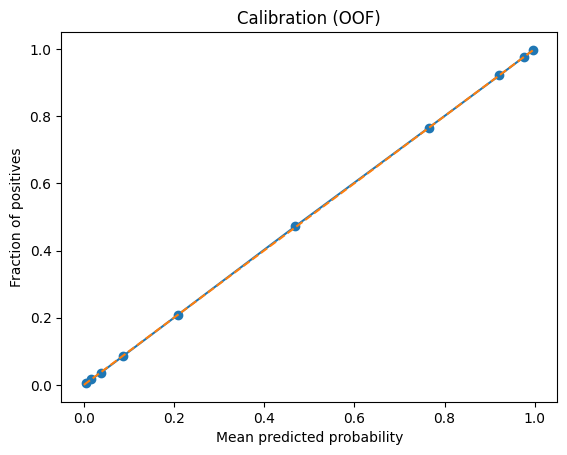

In [84]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

brier = brier_score_loss(oof_df[target], oof_df["oof_pred"])
print("Brier score:", brier)

prob_true, prob_pred = calibration_curve(oof_df[target], oof_df["oof_pred"], n_bins=10, strategy="quantile")

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration (OOF)")
plt.show()


#### ***Where are the errors? (false negatives / false positives)***

The code below **Inspect extreme wrong predictions**

- What you’re trying to learn:
    - Are FNs concentrated in a specific subgroup? (e.g., thallium=3 but disease=1)
    - Are FPs concentrated in another subgroup? (e.g., cp=4 but disease=0)

This tells you whether adding features / interactions could help, or whether labels are noisy.

In [91]:
oof_df["pred_label_05"] = (oof_df["oof_pred"] >= 0.5).astype(int)
oof_df["error"] = (oof_df["pred_label_05"] != oof_df[target]).astype(int)

# False positives: predicted high, actually 0
fp = oof_df[(oof_df[target]==0)].sort_values("oof_pred", ascending=False).head(50)

# False negatives: predicted low, actually 1
fn = oof_df[(oof_df[target]==1)].sort_values("oof_pred", ascending=True).head(50)

fp[features + [target, "oof_pred"]].head(10), fn[features + [target, "oof_pred"]].head(10)

(        age   bp  cholesterol  max_hr  st_depression  number_of_vessels_fluro  \
 236911   67  135          304     142            2.8                        2   
 381300   54  120          266     148            4.5                        2   
 572976   57  150          254     103            1.6                        1   
 441790   44  110          243     122            1.6                        2   
 236244   51  108          303     125            3.4                        3   
 489354   65  130          254     142            1.6                        3   
 131430   43  100          267     130            3.0                        1   
 143227   61  120          199     108            2.0                        0   
 144850   51  140          283     143            2.0                        3   
 273654   58  110          254     118            2.2                        0   
 
         sex  fbs_over_120  exercise_angina  chest_pain_type  ekg_results  \
 236911    1       

#### ***Slice analysis: AUC by subgroup***

Interpretation: 

- If a subgroup has notably lower AUC, the model is failing there.
- If pred_mean is far from base_rate, it’s systematically biased for that subgroup.

In [92]:
def auc_by_group(df, group_col, min_n=2000):
    rows = []
    for g, sub in df.groupby(group_col):
        if len(sub) < min_n:
            continue
        if sub[target].nunique() < 2:
            continue
        auc = roc_auc_score(sub[target], sub["oof_pred"])
        rows.append((group_col, g, len(sub), auc, sub[target].mean(), sub["oof_pred"].mean()))
    return pd.DataFrame(rows, columns=["feature", "level", "n", "auc", "base_rate", "pred_mean"]).sort_values("auc")

for col in categorical_features:
    display(auc_by_group(oof_df, col, min_n=2000).head(20))

,feature,level,n,auc,base_rate,pred_mean
1,sex,1,450283,0.946836,0.555933,0.555897
0,sex,0,179717,0.947604,0.178764,0.178800


,feature,level,n,auc,base_rate,pred_mean
0,fbs_over_120,0,579608,0.955265,0.443417,0.443380
1,fbs_over_120,1,50392,0.957868,0.504961,0.505188


,feature,level,n,auc,base_rate,pred_mean
0,exercise_angina,0,457553,0.939902,0.313433,0.313420
1,exercise_angina,1,172447,0.944401,0.806288,0.806265


,feature,level,n,auc,base_rate,pred_mean
1,chest_pain_type,2,74941,0.926631,0.162181,0.162205
2,chest_pain_type,3,197278,0.930922,0.190665,0.190614
0,chest_pain_type,1,28602,0.932377,0.108069,0.108428
3,chest_pain_type,4,329179,0.932532,0.697478,0.697442


,feature,level,n,auc,base_rate,pred_mean
0,ekg_results,0,320116,0.950952,0.341498,0.341482
1,ekg_results,2,308562,0.954223,0.559560,0.559544


,feature,level,n,auc,base_rate,pred_mean
0,slope_of_st,1,358293,0.938433,0.262257,0.262274
1,slope_of_st,2,256215,0.946299,0.692067,0.692021
2,slope_of_st,3,15492,0.948693,0.721082,0.720824


,feature,level,n,auc,base_rate,pred_mean
2,thallium,7,246748,0.909433,0.815391,0.815369
1,thallium,6,10966,0.916768,0.686394,0.686277
0,thallium,3,372286,0.923587,0.198049,0.198040


What I learned:

- False negative and false positive are inconsistent with SHAP; 

#### ***Global feature importance - SHAP***

Feature importance from splits can lie. SHAP is closer to “how it’s making decisions.”

In [94]:
# Fit one model on full data for interpretation
full_pool = Pool(X, y, cat_features=cat_idx)
m_full = CatBoostClassifier(**v4_params)
m_full.fit(full_pool)

shap_values = m_full.get_feature_importance(full_pool, type="ShapValues")
# shap_values shape: (n_samples, n_features + 1) last column is expected value
shap = shap_values[:, :-1]
shap_abs_mean = np.mean(np.abs(shap), axis=0)

imp = pd.DataFrame({"feature": features, "mean_abs_shap": shap_abs_mean}).sort_values("mean_abs_shap", ascending=False)
imp.head(20)


,feature,mean_abs_shap
9,chest_pain_type,0.932438
12,thallium,0.914842
3,max_hr,0.781805
5,number_of_vessels_fluro,0.662714
8,exercise_angina,0.494200
6,sex,0.479384
11,slope_of_st,0.466778
4,st_depression,0.400039
0,age,0.366430
10,ekg_results,0.219578


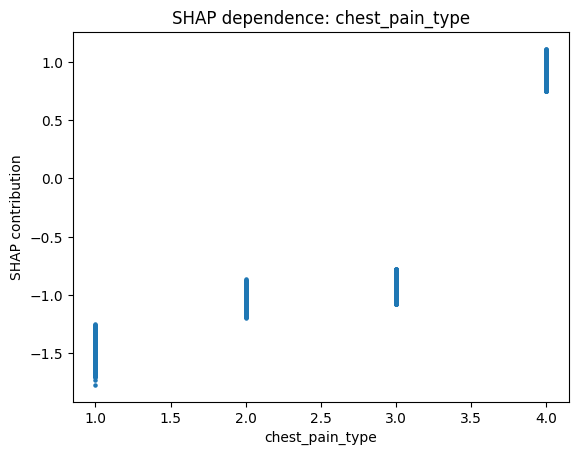

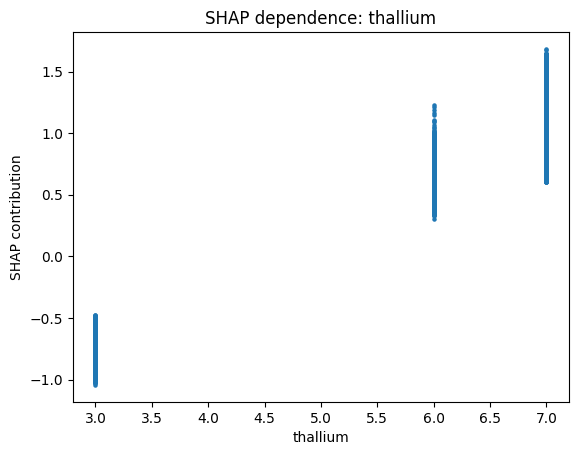

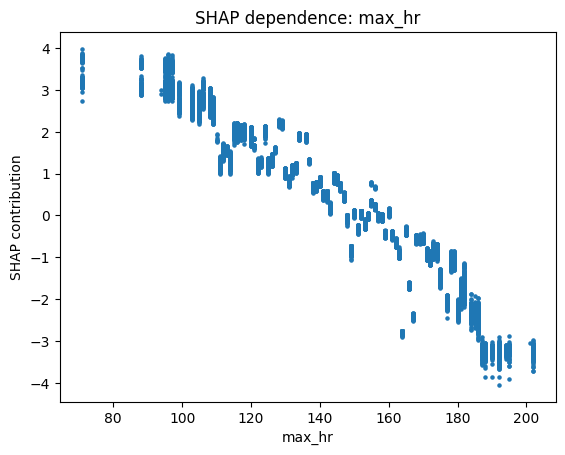

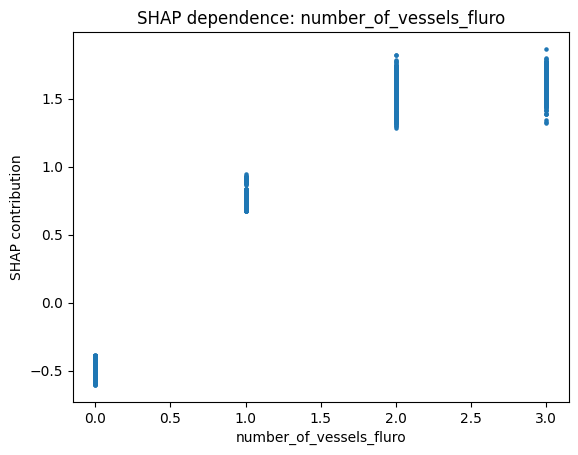

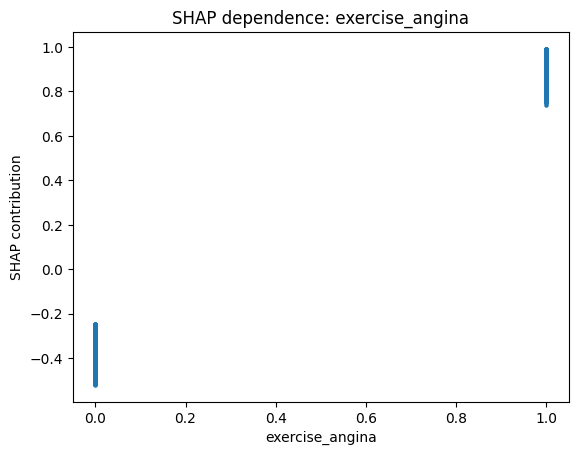

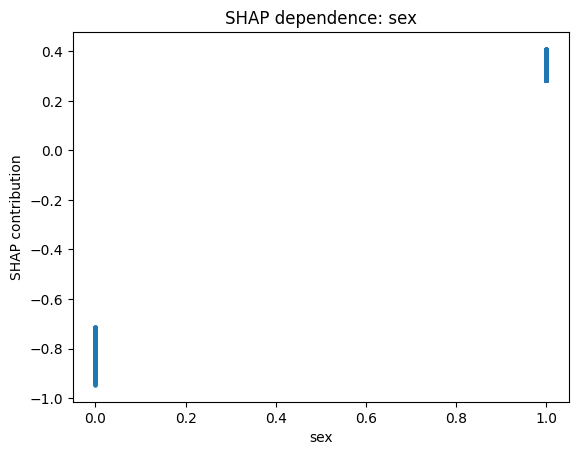

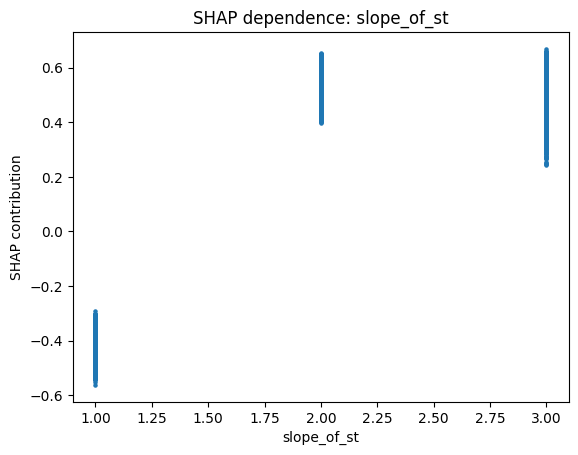

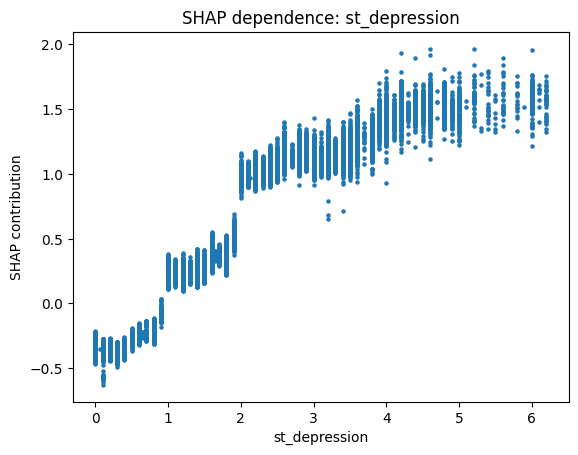

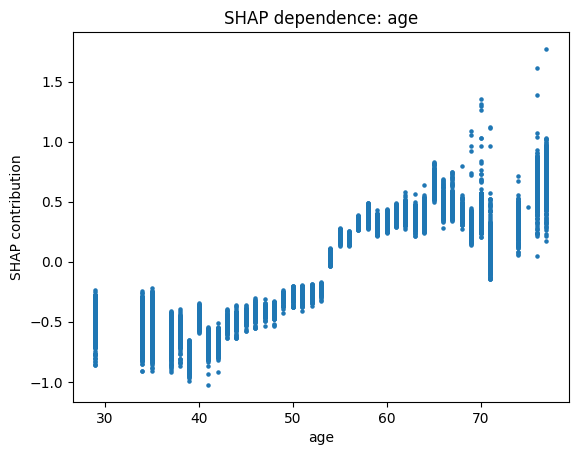

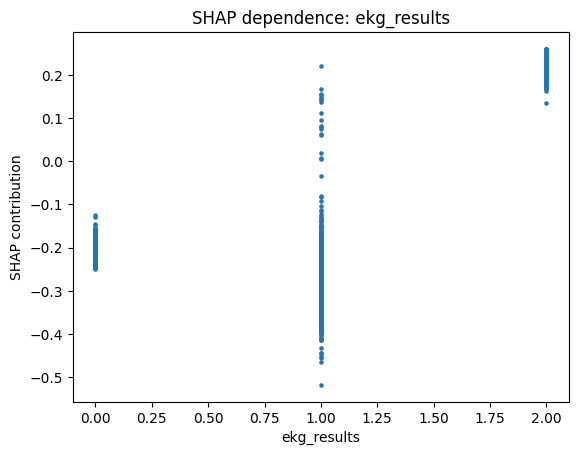

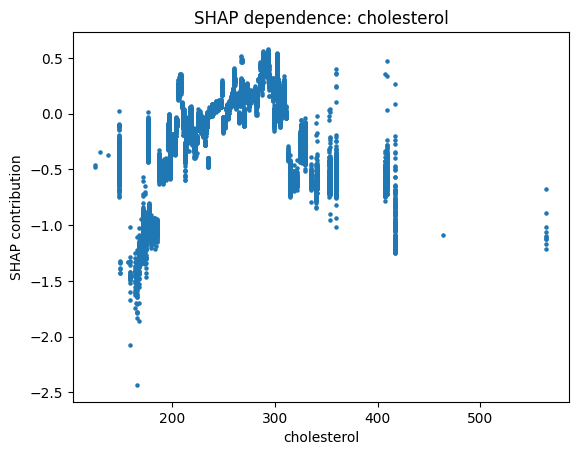

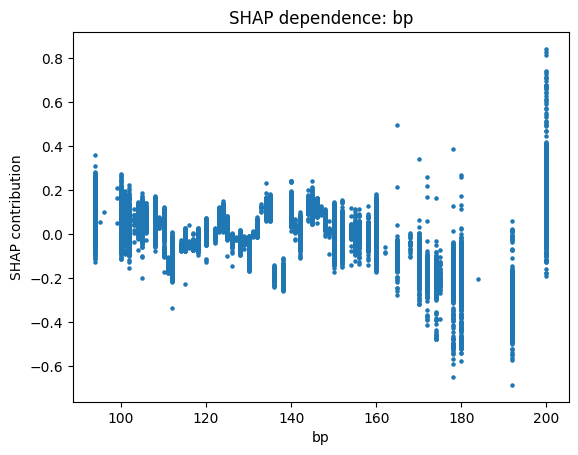

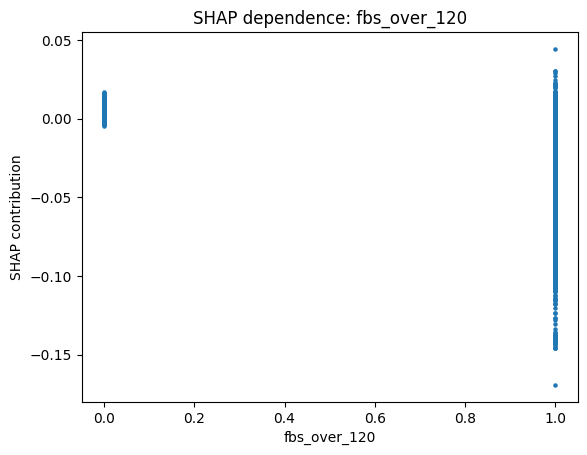

In [96]:
import matplotlib.pyplot as plt

top = imp["feature"].tolist()
for f in top:
    j = features.index(f)
    plt.figure()
    plt.scatter(X[f], shap[:, j], s=5)
    plt.xlabel(f)
    plt.ylabel("SHAP contribution")
    plt.title(f"SHAP dependence: {f}")
    plt.show()


In [97]:
df = train_data.drop(columns=["id"]).copy()

high_risk = (
    (df["chest_pain_type"] == 4) &
    (df["exercise_angina"] == 1) &
    (df["ekg_results"] == 2) &
    (df["number_of_vessels_fluro"] >= 2) &
    (df["thallium"] == 7)
)

low_risk = (
    (df["thallium"] == 3) &
    (df["number_of_vessels_fluro"] == 0) &
    (df["exercise_angina"] == 0) &
    (df["st_depression"] <= 0.1) &
    (df["max_hr"] >= 170)
)

print("High-risk count:", high_risk.sum())
print("High-risk label=0 count:", ((high_risk) & (df["heart_disease"]==0)).sum())

print("Low-risk count:", low_risk.sum())
print("Low-risk label=1 count:", ((low_risk) & (df["heart_disease"]==1)).sum())


High-risk count: 18562
High-risk label=0 count: 108
Low-risk count: 58903
Low-risk label=1 count: 1783


In [98]:
cols = ["age","bp","cholesterol","max_hr","st_depression","number_of_vessels_fluro",
        "sex","fbs_over_120","exercise_angina","chest_pain_type","ekg_results","slope_of_st","thallium"]

dup = train_data.groupby(cols)["heart_disease"].nunique().reset_index(name="n_unique_labels")
contradictory = dup[dup["n_unique_labels"] > 1]
print("Contradictory feature-patterns:", len(contradictory))
contradictory.head(10)


Contradictory feature-patterns: 0


,age,bp,cholesterol,max_hr,st_depression,number_of_vessels_fluro,sex,fbs_over_120,exercise_angina,chest_pain_type,ekg_results,slope_of_st,thallium,n_unique_labels


#### Experiment with weights

In [99]:


df = train_data.drop(columns=["id"]).copy()

features = ["age","bp","cholesterol","max_hr","st_depression","number_of_vessels_fluro",
            "sex","fbs_over_120","exercise_angina","chest_pain_type","ekg_results","slope_of_st","thallium"]
target = "heart_disease"
categorical_features = ["sex","fbs_over_120","exercise_angina","chest_pain_type","ekg_results","slope_of_st","thallium"]

X = df[features].copy()
y = df[target].astype(int).copy()
cat_idx = [X.columns.get_loc(c) for c in categorical_features]

# Your two “rule-contradicting” groups
high_risk = (
    (df["chest_pain_type"] == 4) &
    (df["exercise_angina"] == 1) &
    (df["ekg_results"] == 2) &
    (df["number_of_vessels_fluro"] >= 2) &
    (df["thallium"] == 7)
)
hard_neg = high_risk & (y == 0)

low_risk = (
    (df["thallium"] == 3) &
    (df["number_of_vessels_fluro"] == 0) &
    (df["exercise_angina"] == 0) &
    (df["st_depression"] <= 0.1) &
    (df["max_hr"] >= 170)
)
hard_pos = low_risk & (y == 1)  # these are your “false-negative style” cases

# --- weights ---
w = np.ones(len(df), dtype=float)

POS_UP = 2.0      # try 1.5, 2, 3
NEG_DOWN = 1.0    # optionally 0.5 or 0.2
w[hard_pos.values] *= POS_UP
w[hard_neg.values] *= NEG_DOWN

print("hard_pos:", hard_pos.sum(), "hard_neg:", hard_neg.sum())

# Use your best V4 params here (make sure iterations etc. are ints)
params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    allow_writing_files=False,
    verbose=False,
    thread_count=-1,
    # paste your chosen params (depth, learning_rate, l2_leaf_reg, border_count, etc.)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs, aucs_hardpos = [], []
mean_p_hardpos = []

for tr_idx, va_idx in cv.split(X, y):
    tr_pool = Pool(X.iloc[tr_idx], y.iloc[tr_idx], cat_features=cat_idx, weight=w[tr_idx])
    va_pool = Pool(X.iloc[va_idx], y.iloc[va_idx], cat_features=cat_idx)

    m = CatBoostClassifier(**params)
    m.fit(tr_pool)

    p = m.predict_proba(va_pool)[:, 1]
    y_va = y.iloc[va_idx].values
    aucs.append(roc_auc_score(y_va, p))

    # subgroup eval (hard_pos within this validation fold)
    hp_mask = hard_pos.iloc[va_idx].values
    if hp_mask.sum() > 0 and len(np.unique(y_va[hp_mask])) > 1:
        aucs_hardpos.append(roc_auc_score(y_va[hp_mask], p[hp_mask]))
    mean_p_hardpos.append(float(np.mean(p[hp_mask])) if hp_mask.sum() else np.nan)

print("CV AUC mean/std:", float(np.mean(aucs)), float(np.std(aucs)))
print("Hard-pos AUC mean (where defined):", float(np.mean(aucs_hardpos)) if aucs_hardpos else None)
print("Mean predicted p on hard_pos (per fold):", mean_p_hardpos)


hard_pos: 1783 hard_neg: 108
CV AUC mean/std: 0.9550356471495242 0.00043524109881651633
Hard-pos AUC mean (where defined): None
Mean predicted p on hard_pos (per fold): [0.17095528545417585, 0.17848636665867584, 0.17270391842082589, 0.16283713217757848, 0.17406728461234255]


In [100]:
(y==1).sum()

np.int64(282454)

In [101]:
hard_pos = low_risk & (y==1)
hard_neg_like = low_risk & (y==0)

df_hp = df.loc[hard_pos, features + [target]]
df_hn = df.loc[hard_neg_like, features + [target]]

print(len(df_hp), len(df_hn))
print(df_hp.describe(include="all").T[["mean","std"]])
print(df_hn.describe(include="all").T[["mean","std"]])


1783 57120
                               mean        std
age                       55.690970   7.769286
bp                       130.913629  15.455753
cholesterol              245.007852  32.601201
max_hr                   174.296130   3.894055
st_depression              0.001626   0.012653
number_of_vessels_fluro    0.000000   0.000000
sex                        0.799215   0.400700
fbs_over_120               0.072350   0.259139
exercise_angina            0.000000   0.000000
chest_pain_type            3.578239   0.696647
ekg_results                0.973079   0.999076
slope_of_st                1.347168   0.511431
thallium                   3.000000   0.000000
heart_disease              1.000000   0.000000
                               mean        std
age                       52.276838   8.336146
bp                       130.651085  15.335174
cholesterol              241.714881  33.997773
max_hr                   175.707020   5.083625
st_depression              0.001808   0.013326
nu

In [102]:
from sklearn.metrics import roc_auc_score

mask = (low_risk)  # both labels in here
p_all = model.predict_proba(Pool(X[mask], y[mask], cat_features=cat_idx))[:,1]
auc_contrast = roc_auc_score(y[mask], p_all)
print("AUC within low-risk signature:", auc_contrast)


AUC within low-risk signature: 0.8353112809902424


1) What differentiates low-risk positives vs low-risk negatives?

Within low_risk (thallium=3, vessels=0, exang=0, st_dep≈0, max_hr high):

Biggest shifts in means (positives minus negatives)

sex: 0.799 vs 0.517 → very large shift (more sex=1 among positives)

chest_pain_type: 3.58 vs 2.88 → positives skew toward higher chest pain code (more “3/4”)

ekg_results: 0.97 vs 0.71 → positives skew toward higher EKG code

age: 55.7 vs 52.3 → older

slope_of_st: 1.35 vs 1.16 → slightly higher slope code

cholesterol/bp: small differences

So even when thallium/vessels/exang say “low risk”, sex + chest pain + ekg + age/slope still carry substantial discriminative information.

In [ ]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# ----------------------------
# 0) Feature engineering
# ----------------------------
def treat_dataset(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    # rename column names for easier access
    data.columns = [col.lower().replace(" ", "_") for col in data.columns]

    # convert heart_disease to binary (if present)
    if "heart_disease" in data.columns:
        data["heart_disease"] = data["heart_disease"].apply(
            lambda x: 0 if (x == "Absence" or x == 0) else 1
        ).astype(int)

    # low-risk signature
    data["low_risk_sig"] = (
        (data["thallium"] == 3) &
        (data["number_of_vessels_fluro"] == 0) &
        (data["exercise_angina"] == 0) &
        (data["st_depression"] <= 0.1) &
        (data["max_hr"] >= 170)
    ).astype(int)

    # interactions inside low-risk
    data["low_risk_sex"] = (data["low_risk_sig"].astype(int) * data["sex"].astype(int)).astype(int)

    # NOTE: you wrote age<=50, but your stats suggest older is higher risk in this slice.
    # Consider changing to (age >= 55) instead.
    data["low_risk_age"] = (data["low_risk_sig"].astype(int) * (data["age"] <= 50).astype(int)).astype(int)

    return data


# ----------------------------
# 1) Define feature lists
# ----------------------------
target = "heart_disease"

numeric_features = [
    "age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro",
    "low_risk_sig", "low_risk_sex", "low_risk_age"  # engineered (binary numeric)
]

categorical_features = [
    "sex", "fbs_over_120", "exercise_angina",
    "chest_pain_type", "ekg_results", "slope_of_st", "thallium"
]

features = numeric_features + categorical_features


# ----------------------------
# 2) Prepare training data
# ----------------------------
train_df = treat_dataset(train_data)

# drop id if exists
if "id" in train_df.columns:
    train_df = train_df.drop(columns=["id"])

X = train_df[features].copy()
y = train_df[target].astype(int).copy()

cat_idx = [X.columns.get_loc(c) for c in categorical_features]


# ----------------------------
# 3) Reuse V4 params (start here)
# ----------------------------
v4_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    allow_writing_files=False,
    verbose=False,
    thread_count=-1,
    random_seed=42,

    # your V4-ish settings
    bootstrap_type="Bernoulli",
    iterations=3197,
    learning_rate=0.04571886361,
    depth=3,
    l2_leaf_reg=9.993655205,
    min_data_in_leaf=70,
    rsm=0.7483072281,
    subsample=0.9264181852,
    border_count=192,
    one_hot_max_size=8,
    random_strength=0.8838868141,
)

# ----------------------------
# 4) 5-fold CV on full data (OOF-style evaluation)
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    tr_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
    va_pool = Pool(X_va, y_va, cat_features=cat_idx)

    model = CatBoostClassifier(**v4_params)
    model.fit(tr_pool)

    p = model.predict_proba(va_pool)[:, 1]
    auc = roc_auc_score(y_va, p)
    aucs.append(auc)
    print(f"Fold {fold} AUC: {auc:.6f}")

print(f"\nCV AUC mean: {np.mean(aucs):.6f}  std: {np.std(aucs):.6f}")


# ----------------------------
# 5) Train final model on ALL data and save
# ----------------------------
full_pool = Pool(X, y, cat_features=cat_idx)
final_model = CatBoostClassifier(**v4_params)
final_model.fit(full_pool)

final_model.save_model("catboost_v4_plus_lowrisk.cbm")
print("\nSaved model: catboost_v4_plus_lowrisk.cbm")




Fold 1 AUC: 0.955915
Fold 2 AUC: 0.954849
Fold 3 AUC: 0.955661
Fold 4 AUC: 0.955236
Fold 5 AUC: 0.956049

CV AUC mean: 0.955542  std: 0.000443

Saved model: catboost_v4_plus_lowrisk.cbm


In [105]:
# ----------------------------
# 6) (Optional) Kaggle predictions if you have test_data loaded
# ----------------------------
test_df = treat_dataset(test_data)
if "id" in test_df.columns:
    test_ids = test_df["id"].copy()
else:
    test_ids = pd.Series(np.arange(len(test_df)), name="id")

X_test = test_df[features].copy()
test_pool = Pool(X_test, cat_features=cat_idx)
y_test_proba = final_model.predict_proba(test_pool)[:, 1]

sub = pd.DataFrame({"id": test_ids, "heart_disease": y_test_proba})
sub.to_csv("submission_v4_plus_lowrisk.csv", index=False)
print("Wrote: submission_v4_plus_lowrisk.csv")


Wrote: submission_v4_plus_lowrisk.csv


## Logistic Regression Experimentation

LR Holdout ROC-AUC: 0.953762

In [106]:
import os
import json
import tempfile
import numpy as np
import pandas as pd

import mlflow
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ----------------------------
# 0) MLflow setup (adjust to your env)
# ----------------------------
# If you're using sqlite + artifacts one level above, keep these two lines consistent with how you started mlflow UI.
# Comment them out if you're already setting this elsewhere.
# mlflow.set_tracking_uri("sqlite:///../mlflow_db/mlflow.db")
# mlflow.set_experiment("heart_disease_kaggle")

# ----------------------------
# 1) Feature engineering
# ----------------------------
def treat_dataset(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data.columns = [col.lower().replace(" ", "_") for col in data.columns]

    if "heart_disease" in data.columns:
        data["heart_disease"] = data["heart_disease"].apply(
            lambda x: 0 if (x == "Absence" or x == 0) else 1
        ).astype(int)

    data["low_risk_sig"] = (
        (data["thallium"] == 3) &
        (data["number_of_vessels_fluro"] == 0) &
        (data["exercise_angina"] == 0) &
        (data["st_depression"] <= 0.1) &
        (data["max_hr"] >= 170)
    ).astype(int)

    data["low_risk_sex"] = (data["low_risk_sig"] * data["sex"]).astype(int)

    # NOTE: from your subgroup stats, older looked higher-risk; consider flipping this to (age >= 55)
    data["low_risk_age"] = (data["low_risk_sig"] * (data["age"] <= 50).astype(int)).astype(int)

    return data

def drop_id(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=["id"], errors="ignore")

fe_step = FunctionTransformer(treat_dataset, validate=False)
drop_id_step = FunctionTransformer(drop_id, validate=False)

# ----------------------------
# 2) Columns
# ----------------------------
target = "heart_disease"

binary_numeric = ["sex", "fbs_over_120", "exercise_angina", "low_risk_sig", "low_risk_sex", "low_risk_age"]
numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"] + binary_numeric

categorical_features = ["chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
all_features = numeric_features + categorical_features

# ----------------------------
# 3) Data
# ----------------------------
X_raw = train_data.copy()
y = train_data[target].apply(lambda x: 0 if (x == "Absence" or x == 0) else 1).astype(int)

# Holdout split once
X_tr_raw, X_ho_raw, y_tr, y_ho = train_test_split(
    X_raw, y, test_size=0.15, stratify=y, random_state=42
)

# ----------------------------
# 4) Preprocess + model
# ----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

lr_params = dict(
    solver="saga",
    penalty="l2",
    C=1.0,
    max_iter=5000,
    n_jobs=-1,
    random_state=42,
)

lr = LogisticRegression(**lr_params)

model_lr = Pipeline(steps=[
    ("fe", fe_step),
    ("drop_id", drop_id_step),
    ("preprocess", preprocess),
    ("lr", lr),
])

# ----------------------------
# 5) CV + Holdout + MLflow logging
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="logreg_baseline_v1"):
    # log parameters
    mlflow.log_params(lr_params)
    mlflow.log_param("holdout_test_size", 0.15)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("numeric_features", json.dumps(numeric_features))
    mlflow.log_param("categorical_features", json.dumps(categorical_features))

    # also log feature config as artifact (easier to read than params)
    feat_payload = {
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "all_features": all_features,
        "binary_numeric": binary_numeric,
        "notes": {
            "binary_numeric_not_onehot": True,
            "coded_cats_onehot": True
        }
    }
    with tempfile.TemporaryDirectory() as tmpdir:
        feat_path = os.path.join(tmpdir, "features.json")
        with open(feat_path, "w") as f:
            json.dump(feat_payload, f, indent=2)
        mlflow.log_artifact(feat_path, artifact_path="config")

    # CV (manual loop so we can log each fold)
    fold_aucs = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_tr_raw, y_tr), 1):
        X_tr_f = X_tr_raw.iloc[tr_idx]
        y_tr_f = y_tr.iloc[tr_idx]
        X_va_f = X_tr_raw.iloc[va_idx]
        y_va_f = y_tr.iloc[va_idx]

        model_lr.fit(X_tr_f, y_tr_f)
        p_va = model_lr.predict_proba(X_va_f)[:, 1]
        auc = roc_auc_score(y_va_f, p_va)
        fold_aucs.append(float(auc))
        mlflow.log_metric(f"cv_auc_fold_{fold}", float(auc))

    cv_mean = float(np.mean(fold_aucs))
    cv_std = float(np.std(fold_aucs))
    mlflow.log_metric("cv_auc_mean", cv_mean)
    mlflow.log_metric("cv_auc_std", cv_std)

    print(f"LR CV ROC-AUC: mean={cv_mean:.6f} std={cv_std:.6f}")

    # Fit on full train split, evaluate holdout
    model_lr.fit(X_tr_raw, y_tr)
    p_ho = model_lr.predict_proba(X_ho_raw)[:, 1]
    ho_auc = float(roc_auc_score(y_ho, p_ho))
    mlflow.log_metric("holdout_auc", ho_auc)

    print(f"LR Holdout ROC-AUC: {ho_auc:.6f}")

    # Save pipeline artifact (pickle)
    with tempfile.TemporaryDirectory() as tmpdir:
        import joblib
        model_path = os.path.join(tmpdir, "logreg_pipeline.joblib")
        joblib.dump(model_lr, model_path)
        mlflow.log_artifact(model_path, artifact_path="model")

    # Tag for easy filtering
    mlflow.set_tag("model_family", "logistic_regression")
    mlflow.set_tag("feature_engineering", "low_risk_sig + interactions")


/usr/local/anaconda3/envs/ml_kaggle/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/anaconda3/envs/ml_kaggle/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/anaconda3/envs/ml_kaggle/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_rati

LR CV ROC-AUC: mean=0.952494 std=0.000334


/usr/local/anaconda3/envs/ml_kaggle/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/anaconda3/envs/ml_kaggle/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LR Holdout ROC-AUC: 0.953762


In [107]:
# generate predictions on Kaggle set
kaggle_df = pd.read_csv("data/test.csv")

kaggle_df_fe = treat_dataset(kaggle_df)
kaggle_X = kaggle_df_fe[all_features].copy()
kaggle_ids = kaggle_df_fe["id"].copy()
kaggle_preds = model_lr.predict_proba(kaggle_X)[:, 1]
submission = pd.DataFrame({"id": kaggle_ids, "heart_disease": kaggle_preds})
submission.to_csv("submission_logreg_v1.csv", index=False)
print("Wrote submission_logreg_v1.csv")

Wrote submission_logreg_v1.csv


In [109]:
# check feature importance via coefficients
feature_names = model_lr.named_steps["preprocess"].get_feature_names_out()
coefs = model_lr.named_steps["lr"].coef_[0]
feat_imp = pd.DataFrame({"feature": feature_names, "coef": coefs})
feat_imp["abs_coef"] = feat_imp["coef"].abs()
feat_imp = feat_imp.sort_values("abs_coef", ascending=False)
print("Top features by absolute coefficient:")
print(feat_imp)

Top features by absolute coefficient:
                    feature      coef  abs_coef
15        chest_pain_type_4  1.416755  1.416755
22               thallium_3 -1.150943  1.150943
12        chest_pain_type_1 -0.839528  0.839528
3                    max_hr -0.833733  0.833733
24               thallium_7  0.806566  0.806566
5   number_of_vessels_fluro  0.692287  0.692287
19            slope_of_st_1 -0.621375  0.621375
8           exercise_angina  0.529352  0.529352
6                       sex  0.473681  0.473681
4             st_depression  0.440398  0.440398
13        chest_pain_type_2 -0.366429  0.366429
0                       age  0.346269  0.346269
23               thallium_6  0.290459  0.290459
18            ekg_results_2  0.289300  0.289300
20            slope_of_st_2  0.287029  0.287029
21            slope_of_st_3  0.280428  0.280428
14        chest_pain_type_3 -0.264716  0.264716
17            ekg_results_1 -0.202281  0.202281
16            ekg_results_0 -0.140937  0.140937
2 

In [112]:
# correlation between V4 and this model
np.corrcoef(kaggle_preds, p_ens_v4)[0, 1]



np.float64(0.9927169068652352)

## XGBoost

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "number_of_vessels_fluro"]
categorical_features = ["sex", "fbs_over_120", "exercise_angina", "chest_pain_type", "ekg_results", "slope_of_st", "thallium"]
features = numeric_features + categorical_features

# ----------------------------
# Params: xgb_reg_shallow
# ----------------------------
base_params = dict(
    n_estimators=8000,
    learning_rate=0.02,
    max_depth=3,
    min_child_weight=8,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=1.0,
    reg_lambda=6.0,
    gamma=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_jobs=-1,
)

seeds = [42, 202, 999, 1337]

# ----------------------------
# Prepare train
# ----------------------------
train_df = train_data.drop(columns=["id"]).copy()
X_train = train_df[features].copy()
y_train = train_df[target].astype(int).copy()

for c in categorical_features:
    X_train[c] = X_train[c].astype("category")

# ----------------------------
# Prepare test (Kaggle)
# ----------------------------
X_test = test_data.drop(columns=["id"], errors="ignore")[features].copy()
for c in categorical_features:
    X_test[c] = X_test[c].astype("category")

# ----------------------------
# Train 4 seeds + ensemble
# ----------------------------
test_preds = []

for seed in seeds:
    params = dict(base_params)
    params["random_state"] = int(seed)

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    p_test = model.predict_proba(X_test)[:, 1]
    test_preds.append(p_test)

p_test_ens = np.mean(np.vstack(test_preds), axis=0)

# ----------------------------
# Save submission
# ----------------------------
sub = pd.DataFrame({"id": test_data["id"], target: p_test_ens})
sub.to_csv("submission_xgb_reg_shallow_4seed.csv", index=False)
print("Saved: submission_xgb_reg_shallow_4seed.csv")



Saved: submission_xgb_reg_shallow_4seed.csv


In [118]:
np.corrcoef(p_ens_v4, p_test_ens)[0, 1]

np.float64(0.9995683670335862)

### Ensemble v4 + xgboost

In [119]:
def make_weighted_ensembles(p_ens_v4, p_test_ens, test_ids, weights=(0.5, 0.7, 0.85), prefix="ens_v4_xgb"):
    """
    p_ens_v4: 1D array-like, V4 probs for Kaggle test (aligned to test_ids)
    p_test_ens: 1D array-like, XGB probs for Kaggle test (aligned to test_ids)
    test_ids: array-like of ids (same order)
    weights: weights for V4; XGB weight = 1-w
    """
    p1 = np.asarray(p_ens_v4).ravel()
    p2 = np.asarray(p_test_ens).ravel()
    ids = np.asarray(test_ids).ravel()

    if not (len(p1) == len(p2) == len(ids)):
        raise ValueError(f"Length mismatch: v4={len(p1)} xgb={len(p2)} ids={len(ids)}")

    out_paths = []
    for w in weights:
        w = float(w)
        p_blend = w * p1 + (1.0 - w) * p2
        sub = pd.DataFrame({"id": ids, target: p_blend})
        path = f"{prefix}_w{int(w*100)}_{int((1-w)*100)}.csv"
        sub.to_csv(path, index=False)
        out_paths.append(path)
        print(f"Saved {path}  (V4={w:.2f}, XGB={1-w:.2f})")

    return out_paths



In [122]:
# Example usage:
make_weighted_ensembles(p_ens_v4, p_test_ens, test_data["id"], weights=(0.45, 0.55, 0.6))

Saved ens_v4_xgb_w45_55.csv  (V4=0.45, XGB=0.55)
Saved ens_v4_xgb_w55_44.csv  (V4=0.55, XGB=0.45)
Saved ens_v4_xgb_w60_40.csv  (V4=0.60, XGB=0.40)


['ens_v4_xgb_w45_55.csv', 'ens_v4_xgb_w55_44.csv', 'ens_v4_xgb_w60_40.csv']

In [123]:
def save_logit_blends(test_ids, p1, p2, weights, out_prefix="logit_v4_xgb", eps=1e-6):
    p1 = np.asarray(p1).ravel()
    p2 = np.asarray(p2).ravel()
    ids = np.asarray(test_ids).ravel()
    assert len(p1) == len(p2) == len(ids)

    def logit(p):
        p = np.clip(p, eps, 1 - eps)
        return np.log(p / (1 - p))

    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    l1, l2 = logit(p1), logit(p2)

    paths = []
    for w in weights:
        w = float(w)
        p = sigmoid(w * l1 + (1 - w) * l2)
        fn = f"{out_prefix}_w{int(round(w*100)):02d}_{int(round((1-w)*100)):02d}.csv"
        pd.DataFrame({"id": ids, "heart_disease": p}).to_csv(fn, index=False)
        paths.append(fn)
        print("saved:", fn)
    return paths



In [124]:
# try same weights as above, or narrower around 0.4–0.55
weights = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
save_logit_blends(test_df["id"], p_ens_v4, p_test_ens, weights)

saved: logit_v4_xgb_w35_65.csv
saved: logit_v4_xgb_w40_60.csv
saved: logit_v4_xgb_w45_55.csv
saved: logit_v4_xgb_w50_50.csv
saved: logit_v4_xgb_w55_45.csv
saved: logit_v4_xgb_w60_40.csv


['logit_v4_xgb_w35_65.csv',
 'logit_v4_xgb_w40_60.csv',
 'logit_v4_xgb_w45_55.csv',
 'logit_v4_xgb_w50_50.csv',
 'logit_v4_xgb_w55_45.csv',
 'logit_v4_xgb_w60_40.csv']

## Tests with low-risk cases

In [153]:
low_risk = train_data[(train_data["low_risk"] == 0)]

In [154]:
# compute the base rate of heart disease in this low-risk group
base_rate_low_risk = low_risk["heart_disease"].mean()
print(f"Base rate of heart disease in low-risk group: {base_rate_low_risk:.4f}")

# overall positive rate in the full training set
overall_base_rate = train_data["heart_disease"].mean()
print(f"Overall base rate of heart disease: {overall_base_rate:.4f}")

# Compare the two
print(f"Low-risk group has a base rate of {base_rate_low_risk:.4f} compared to overall {overall_base_rate:.4f}")

Base rate of heart disease in low-risk group: 0.4915
Overall base rate of heart disease: 0.4483
Low-risk group has a base rate of 0.4915 compared to overall 0.4483


In [159]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# --- choose which rows to train/evaluate on (slice) ---
mask = (train_data["low_risk"] == 1).values  # specialist slice

# --- build X / y ---
drop_cols = ["heart_disease", "id", "low_risk"]  # low_risk is constant inside the slice
X = train_data.loc[mask].drop(columns=[c for c in drop_cols if c in train_data.columns])
y = train_data.loc[mask, "heart_disease"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(y))

for tr_idx, va_idx in skf.split(X, y):
    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )
    model.fit(
        X.iloc[tr_idx], y[tr_idx],
        eval_set=(X.iloc[va_idx], y[va_idx]),
        use_best_model=True
    )
    oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]

print("OOF AUC (specialist on low_risk slice):", roc_auc_score(y, oof))


OOF AUC (specialist on low_risk slice): 0.8116347829092376
